Latency plot

# 4GPUs, latency comparison

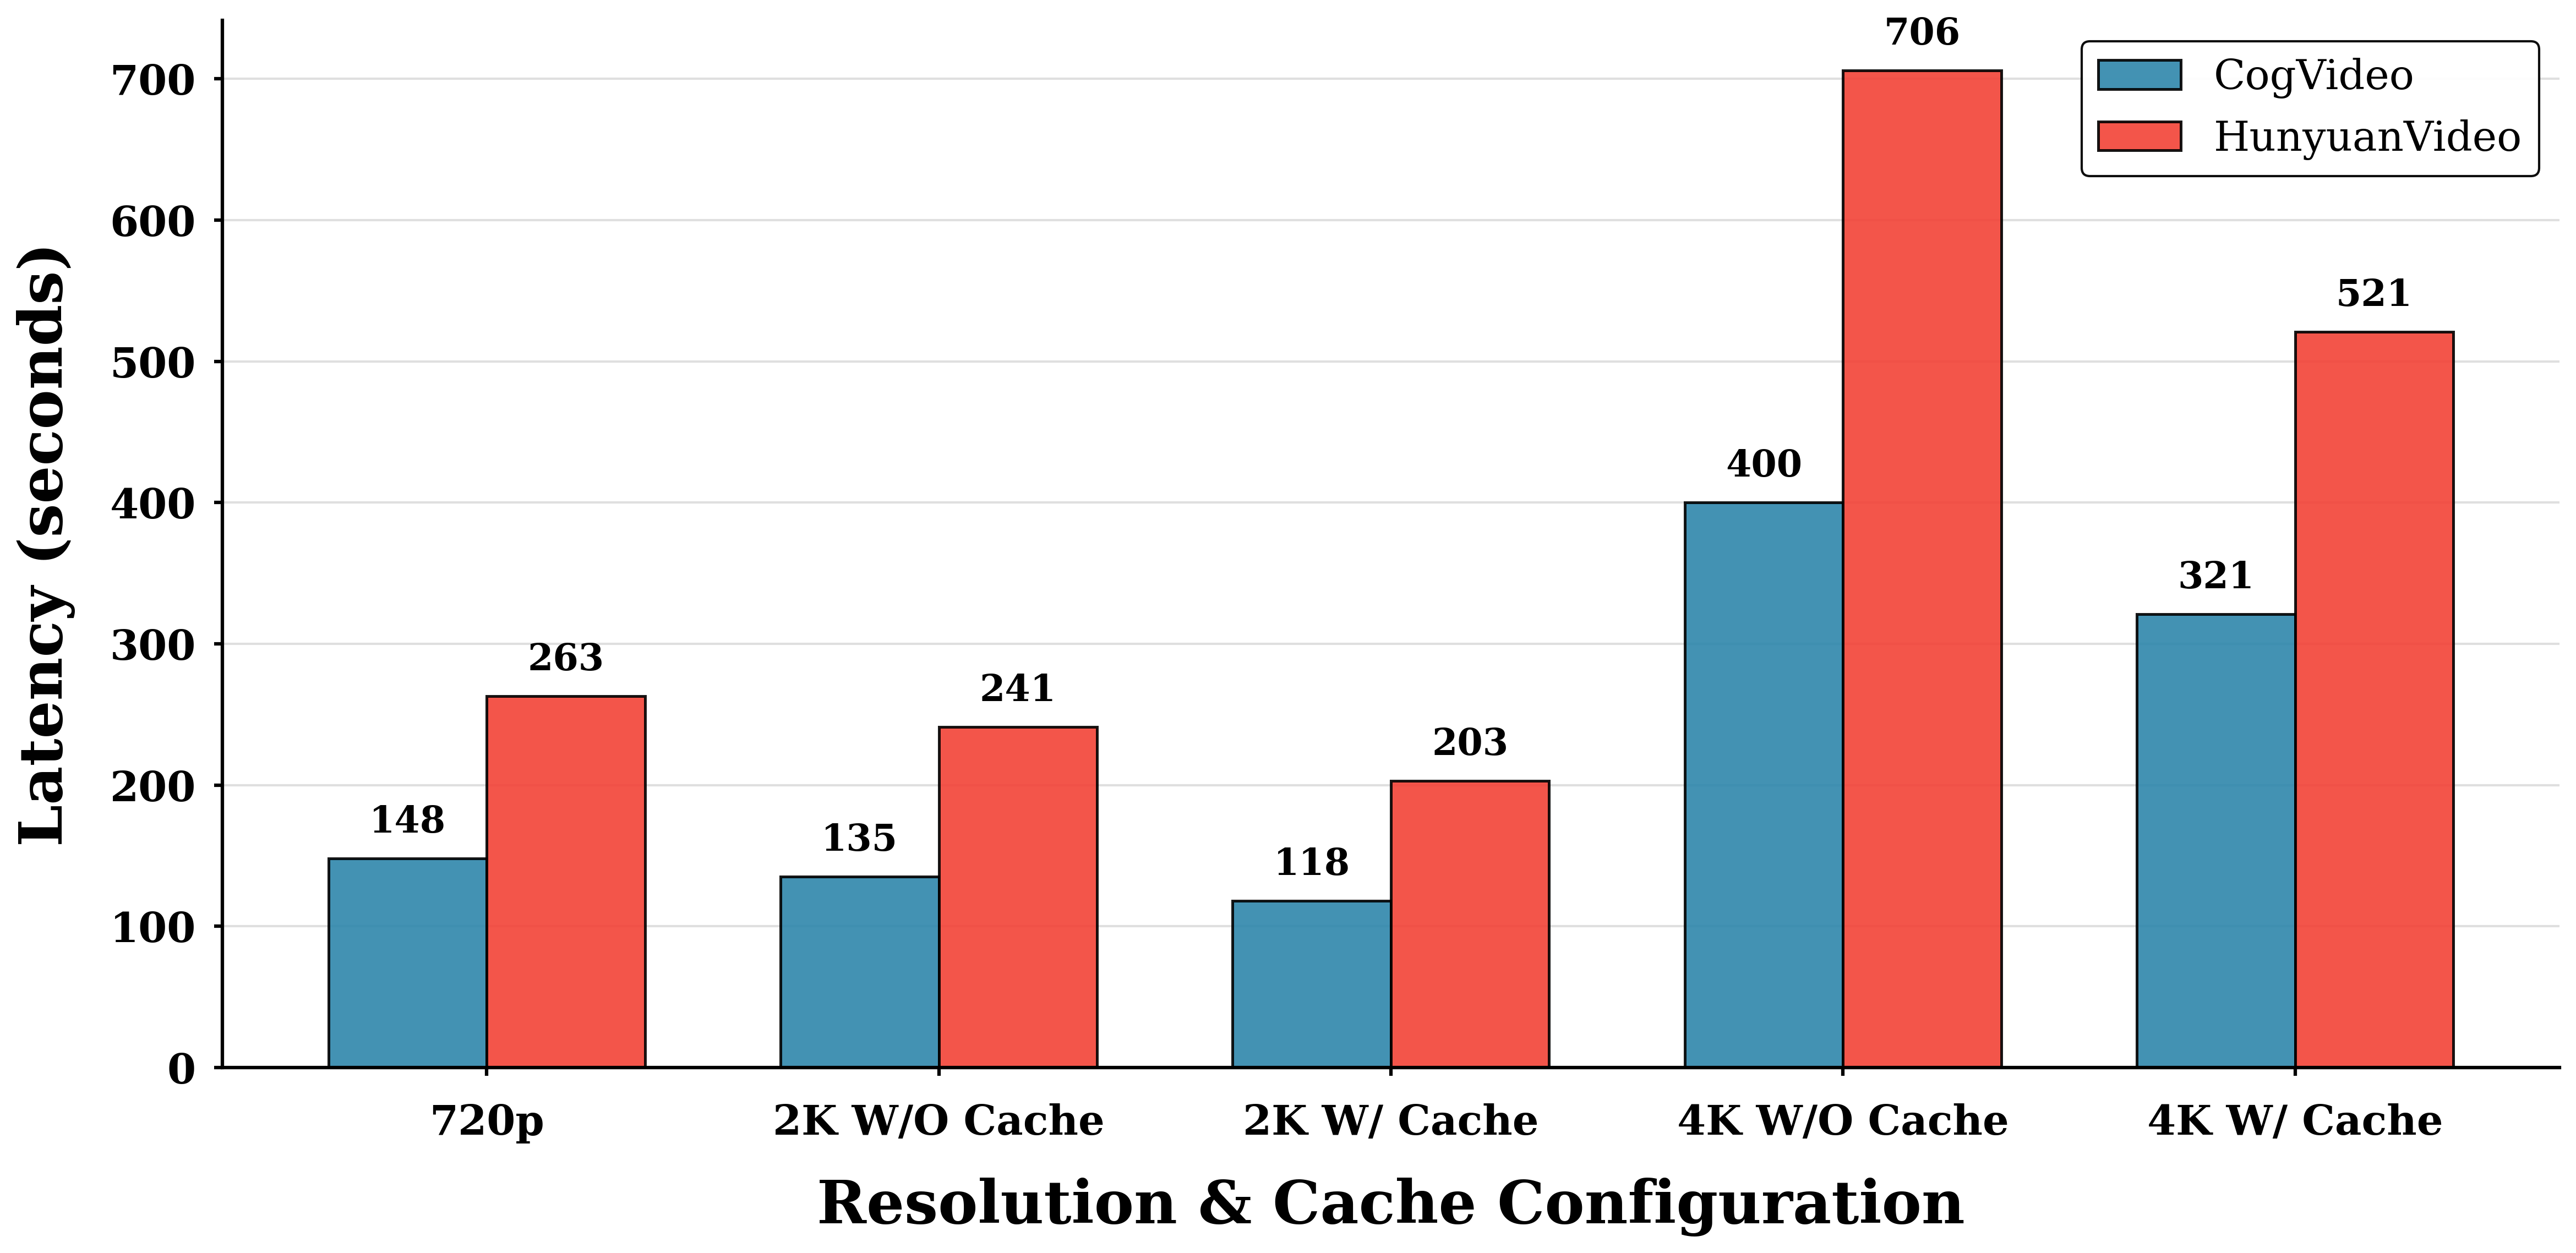

In [144]:
import matplotlib.pyplot as plt
import numpy as np

# 设置matplotlib参数以适配LaTeX论文 - 增大字体和间距
plt.rcParams.update({
    'font.size': 20,           # 从16增加到20
    'axes.titlesize': 22,      # 从18增加到22
    'axes.labelsize': 20,      # 从16增加到20
    'xtick.labelsize': 18,     # 从14增加到18
    'ytick.labelsize': 18,     # 从14增加到18
    'legend.fontsize': 18,     # 从14增加到18
    'font.family': 'serif',
    'text.usetex': False,      # 如果系统有LaTeX可以设为True
    'figure.dpi': 300,
    'xtick.major.pad': 12,     # 增加x轴刻度与标签的距离
    'ytick.major.pad': 8,      # 增加y轴刻度与标签的距离
})

# 数据
models = ['CogVideo', 'HunyuanVideo']
resolutions = ['720p', '2K W/O Cache', '2K W/ Cache', '4K W/O Cache', '4K W/ Cache']

# 延迟数据
cogvideo_latency = [148, 135, 118, 400, 321]
hunyuan_latency = [263, 241, 203, 706, 521]
cogvideo_1gpu_latency = [366, 534]
hunyuan_1gpu_latency = [479, 942]

# 设置柱状图参数
x = np.arange(len(resolutions))  # 标签位置
width = 0.35  # 柱子宽度

# 创建图表，使用更大的图形尺寸
fig, ax = plt.subplots(figsize=(16, 8))  # 增大图形尺寸以容纳更大字体

# 绘制柱状图，使用更高对比度的颜色
bars1 = ax.bar(x - width/2, cogvideo_latency, width, label='CogVideo', 
               alpha=0.9, color='#2E86AB', edgecolor='black', linewidth=1.2)
bars2 = ax.bar(x + width/2, hunyuan_latency, width, label='HunyuanVideo', 
               alpha=0.9, color='#F24236', edgecolor='black', linewidth=1.2)

# 添加数值标签，使用更大字体
def add_value_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 8),  # 从5增加到8，增加垂直偏移
                    textcoords="offset points",
                    ha='center', va='bottom',
                    fontsize=16, fontweight='bold')  # 从14增加到16

add_value_labels(bars1)
add_value_labels(bars2)

# 设置标签和标题，使用更大字体
ax.set_xlabel('Resolution & Cache Configuration', fontsize=26, fontweight='bold', labelpad=15)  # 增加labelpad
ax.set_ylabel('Latency (seconds)', fontsize=26, fontweight='bold', labelpad=15)  # 增加labelpad
ax.set_xticks(x)
ax.set_xticklabels(resolutions, rotation=0, ha='center', fontsize=18, fontweight='bold')  # 增大到18
ax.legend(fontsize=18, framealpha=0.95, edgecolor='black')  # 从16增加到18

# 设置网格，更清晰的网格线
ax.grid(True, alpha=0.4, axis='y', linewidth=1)
ax.set_axisbelow(True)

# 设置坐标轴样式
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

# 设置y轴和x轴刻度字体为粗体
ax.tick_params(axis='y', labelsize=18, width=1.5, pad=8)  # 增加pad
ax.tick_params(axis='x', labelsize=18, width=1.5, pad=12)  # 增加pad

# 手动设置y轴刻度标签为粗体
for label in ax.get_yticklabels():
    label.set_fontweight('bold')

# 调整布局
plt.tight_layout()

# 保存为PDF，使用更高质量设置
plt.savefig('latency_comparison_4GPUs.pdf', format='pdf', bbox_inches='tight', 
            dpi=600, facecolor='white', edgecolor='none')

# 显示图表
plt.show()

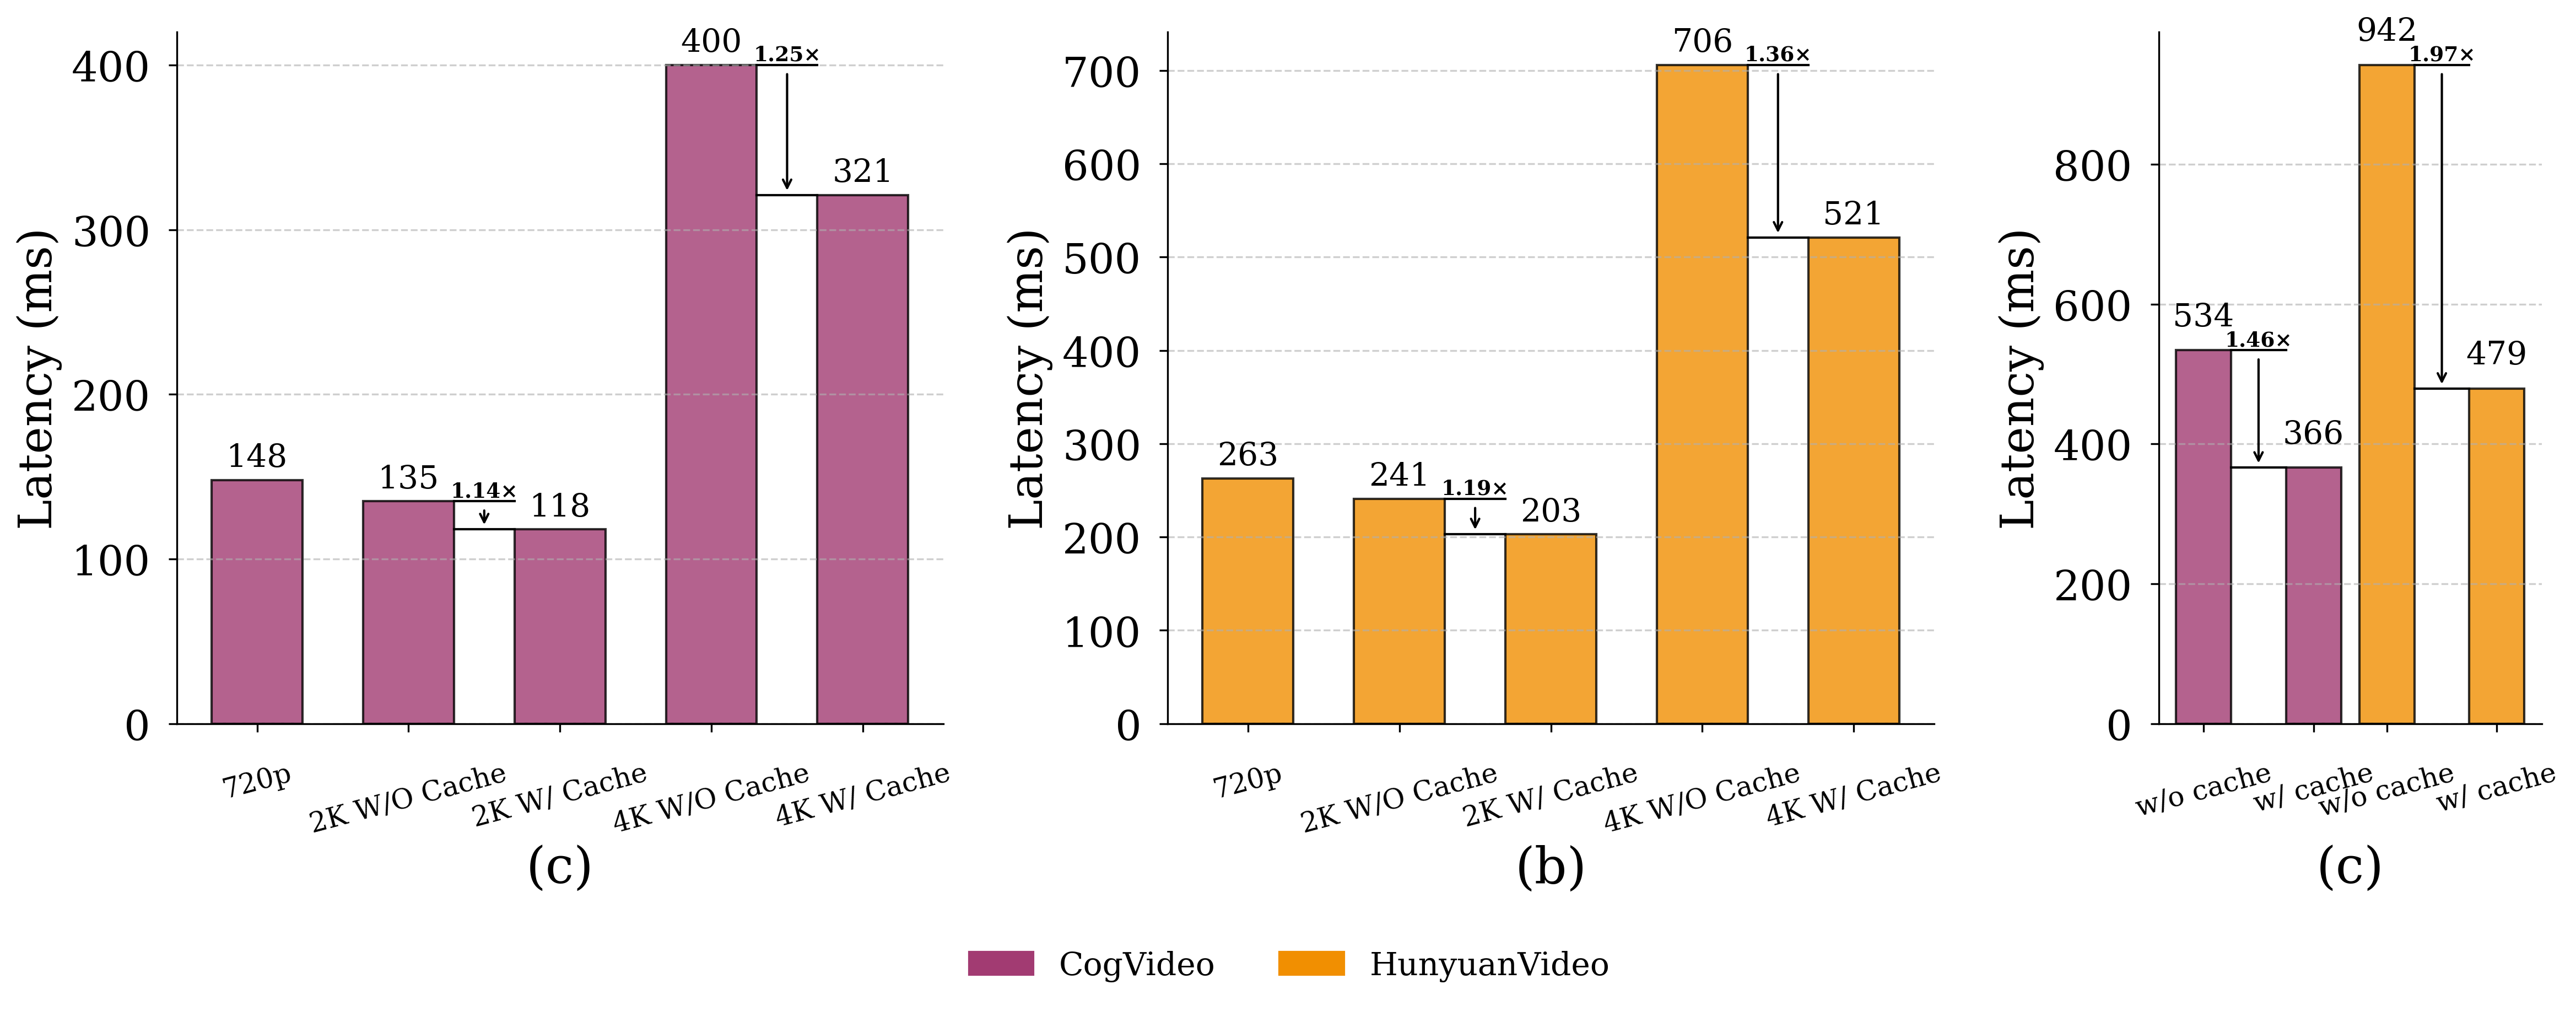

In [51]:
import matplotlib.pyplot as plt
import numpy as np

# Data
resolutions = ['720p', '2K W/O Cache', '2K W/ Cache', '4K W/O Cache', '4K W/ Cache']

cogvideo_latency = [148, 135, 118, 400, 321]
hunyuan_latency = [263, 241, 203, 706, 521]

cogvideo_1gpu_latency = [534, 366]  # [2K W/O, 2K W/]
hunyuan_1gpu_latency = [942, 479]   # [2K W/O, 2K W/]

# Create figure with 3 subplots: CogVideo, HunyuanVideo, and right GPU comparison
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 6), gridspec_kw={'width_ratios': [2, 2, 1]})

colors=["#A23B72", "#F18F01"]

# --- Helper: speedup with dotted line from W/O -> above W/ and arrow to W/ top ---
def annotate_speedup(ax, x_wo, y_wo, x_w, y_w, color='red', width=None):
    """Draw a horizontal dotted line from the W/O cache bar top to above the W/ cache bar,
    then an arrow from that line to the top of the W/ cache bar, and label the speedup."""
    speedup = y_wo / y_w
    half_width = width / 2
    color="black"
    # Horizontal dotted line spanning from W/O bar top to above the W/ bar
    ax.plot([x_wo + half_width, x_w - half_width], [y_wo, y_wo], linestyle='-', linewidth=1, color=color)
    ax.plot([x_wo + half_width, x_w - half_width], [y_w, y_w], linestyle='-', linewidth=1, color=color)
    center_x = (x_wo + x_w) / 2
    # Arrow from that line down to the W/ cache bar top with label
    ax.annotate(f"{speedup:.2f}×",
                xy=(center_x, y_w),            # arrow tip at W/ bar top
                xytext=(center_x, y_wo),       # start on the dotted line above W/
                textcoords='data',
                ha='center', va='bottom', fontsize=9, color=color, fontweight='bold',
                arrowprops=dict(arrowstyle='->', lw=1, color=color))

# --- CogVideo subplot ---
x = np.arange(len(resolutions))
width = 0.6  # wider bars

bars1 = ax1.bar(x, cogvideo_latency, width, label='CogVideo', color=colors[0], edgecolor='black', linewidth=1, alpha=0.8)
ax1.set_xticks(x)
ax1.set_xticklabels(resolutions, rotation=15, ha='center', fontsize=12)
ax1.set_ylabel('Latency (ms)')
ax1.set_title('(c)', y=-0.25)

ax1.spines['right'].set_visible(False)
ax1.spines['top'].set_visible(False)
ax1.grid(True, axis='y', linestyle='--', alpha=0.6)

for bar in bars1:
    height = bar.get_height()
    ax1.annotate(f'{height}',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3),
                 textcoords="offset points",
                 ha='center', va='bottom', fontsize=14)

# Speedups for CogVideo (2K and 4K)
annotate_speedup(ax1, x_wo=1, y_wo=cogvideo_latency[1], x_w=2, y_w=cogvideo_latency[2], color='red', width=width)
annotate_speedup(ax1, x_wo=3, y_wo=cogvideo_latency[3], x_w=4, y_w=cogvideo_latency[4], color='red', width=width)

# --- HunyuanVideo subplot ---
x2 = np.arange(len(resolutions))
bars2 = ax2.bar(x2, hunyuan_latency, width, label='HunyuanVideo', color=colors[1], edgecolor='black', linewidth=1, alpha=0.8)
ax2.set_xticks(x2)
ax2.set_xticklabels(resolutions, rotation=15, ha='center', fontsize=12)
ax2.set_ylabel('Latency (ms)')
ax2.set_title('(b)', y=-0.25)

ax2.spines['right'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax2.grid(True, axis='y', linestyle='--', alpha=0.6)

for bar in bars2:
    height = bar.get_height()
    ax2.annotate(f'{height}',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3),
                 textcoords="offset points",
                 ha='center', va='bottom', fontsize=14)

# Speedups for HunyuanVideo (2K and 4K)
annotate_speedup(ax2, x_wo=1, y_wo=hunyuan_latency[1], x_w=2, y_w=hunyuan_latency[2], color='purple', width=width)
annotate_speedup(ax2, x_wo=3, y_wo=hunyuan_latency[3], x_w=4, y_w=hunyuan_latency[4], color='purple', width=width)

# --- Right subplot (group by Model; bars = W/O vs W/ within each group) ---
models = ['CogVideo', 'HunyuanVideo']
xg = np.arange(0, len(models) * 2, step=2)
width3 = 0.6
gap = 1.2

# Bars: for each model group, left = 2K W/O, right = 2K W/
bar3_x = [xg[0]-gap/2, xg[0] + gap/2]
bar3_y = [cogvideo_1gpu_latency[0], cogvideo_1gpu_latency[1]]
bar4_x = [xg[1]-gap/2, xg[1] + gap/2]
bar4_y = [hunyuan_1gpu_latency[0], hunyuan_1gpu_latency[1]]
bars3 = ax3.bar(bar3_x, bar3_y, width3, label='2K W/O Cache', edgecolor='black', linewidth=1, alpha=0.8, color=colors[0])
bars4 = ax3.bar(bar4_x, bar4_y, width3, label='2K W/ Cache', edgecolor='black', linewidth=1, alpha=0.8, color=colors[1])

ax3.set_xticks(bar3_x + bar4_x)
ax3.set_xticklabels(['w/o cache', 'w/ cache'] * 2, rotation=15, ha='center', fontsize=12)
ax3.set_ylabel('Latency (ms)')
ax3.set_title('(c)', y=-0.25)
# ax3.legend()

ax3.spines['right'].set_visible(False)
ax3.spines['top'].set_visible(False)
ax3.grid(True, axis='y', linestyle='--', alpha=0.6)

for bar in list(bars3) + list(bars4):
    height = bar.get_height()
    ax3.annotate(f'{height}',
                 xy=(bar.get_x() + bar.get_width() / 2, height+16),
                 xytext=(0, 3),
                 textcoords="offset points",
                 ha='center', va='bottom', fontsize=14)

# Speedups per model on the right subplot
# CogVideo group (index 0)
annotate_speedup(ax3,
                 x_wo=bar3_x[0], y_wo=bar3_y[0],
                 x_w=bar3_x[1], y_w=bar3_y[1], color='red', width=width3)
# HunyuanVideo group (index 1)
annotate_speedup(ax3,
                 x_wo=bar4_x[0], y_wo=bar4_y[0],
                 x_w=bar4_x[1], y_w=bar4_y[1], color='purple', width=width3)

import matplotlib.patches as mpatches
legend_patches = [mpatches.Patch(color=colors[i], label=models[i]) for i in range(len(models))]
fig.legend(handles=legend_patches, loc='lower center', bbox_to_anchor=(0.5, -0.05), 
           ncol=3, fontsize=14, frameon=False)

fig.savefig('latency_comparison_4GPUs.pdf', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()


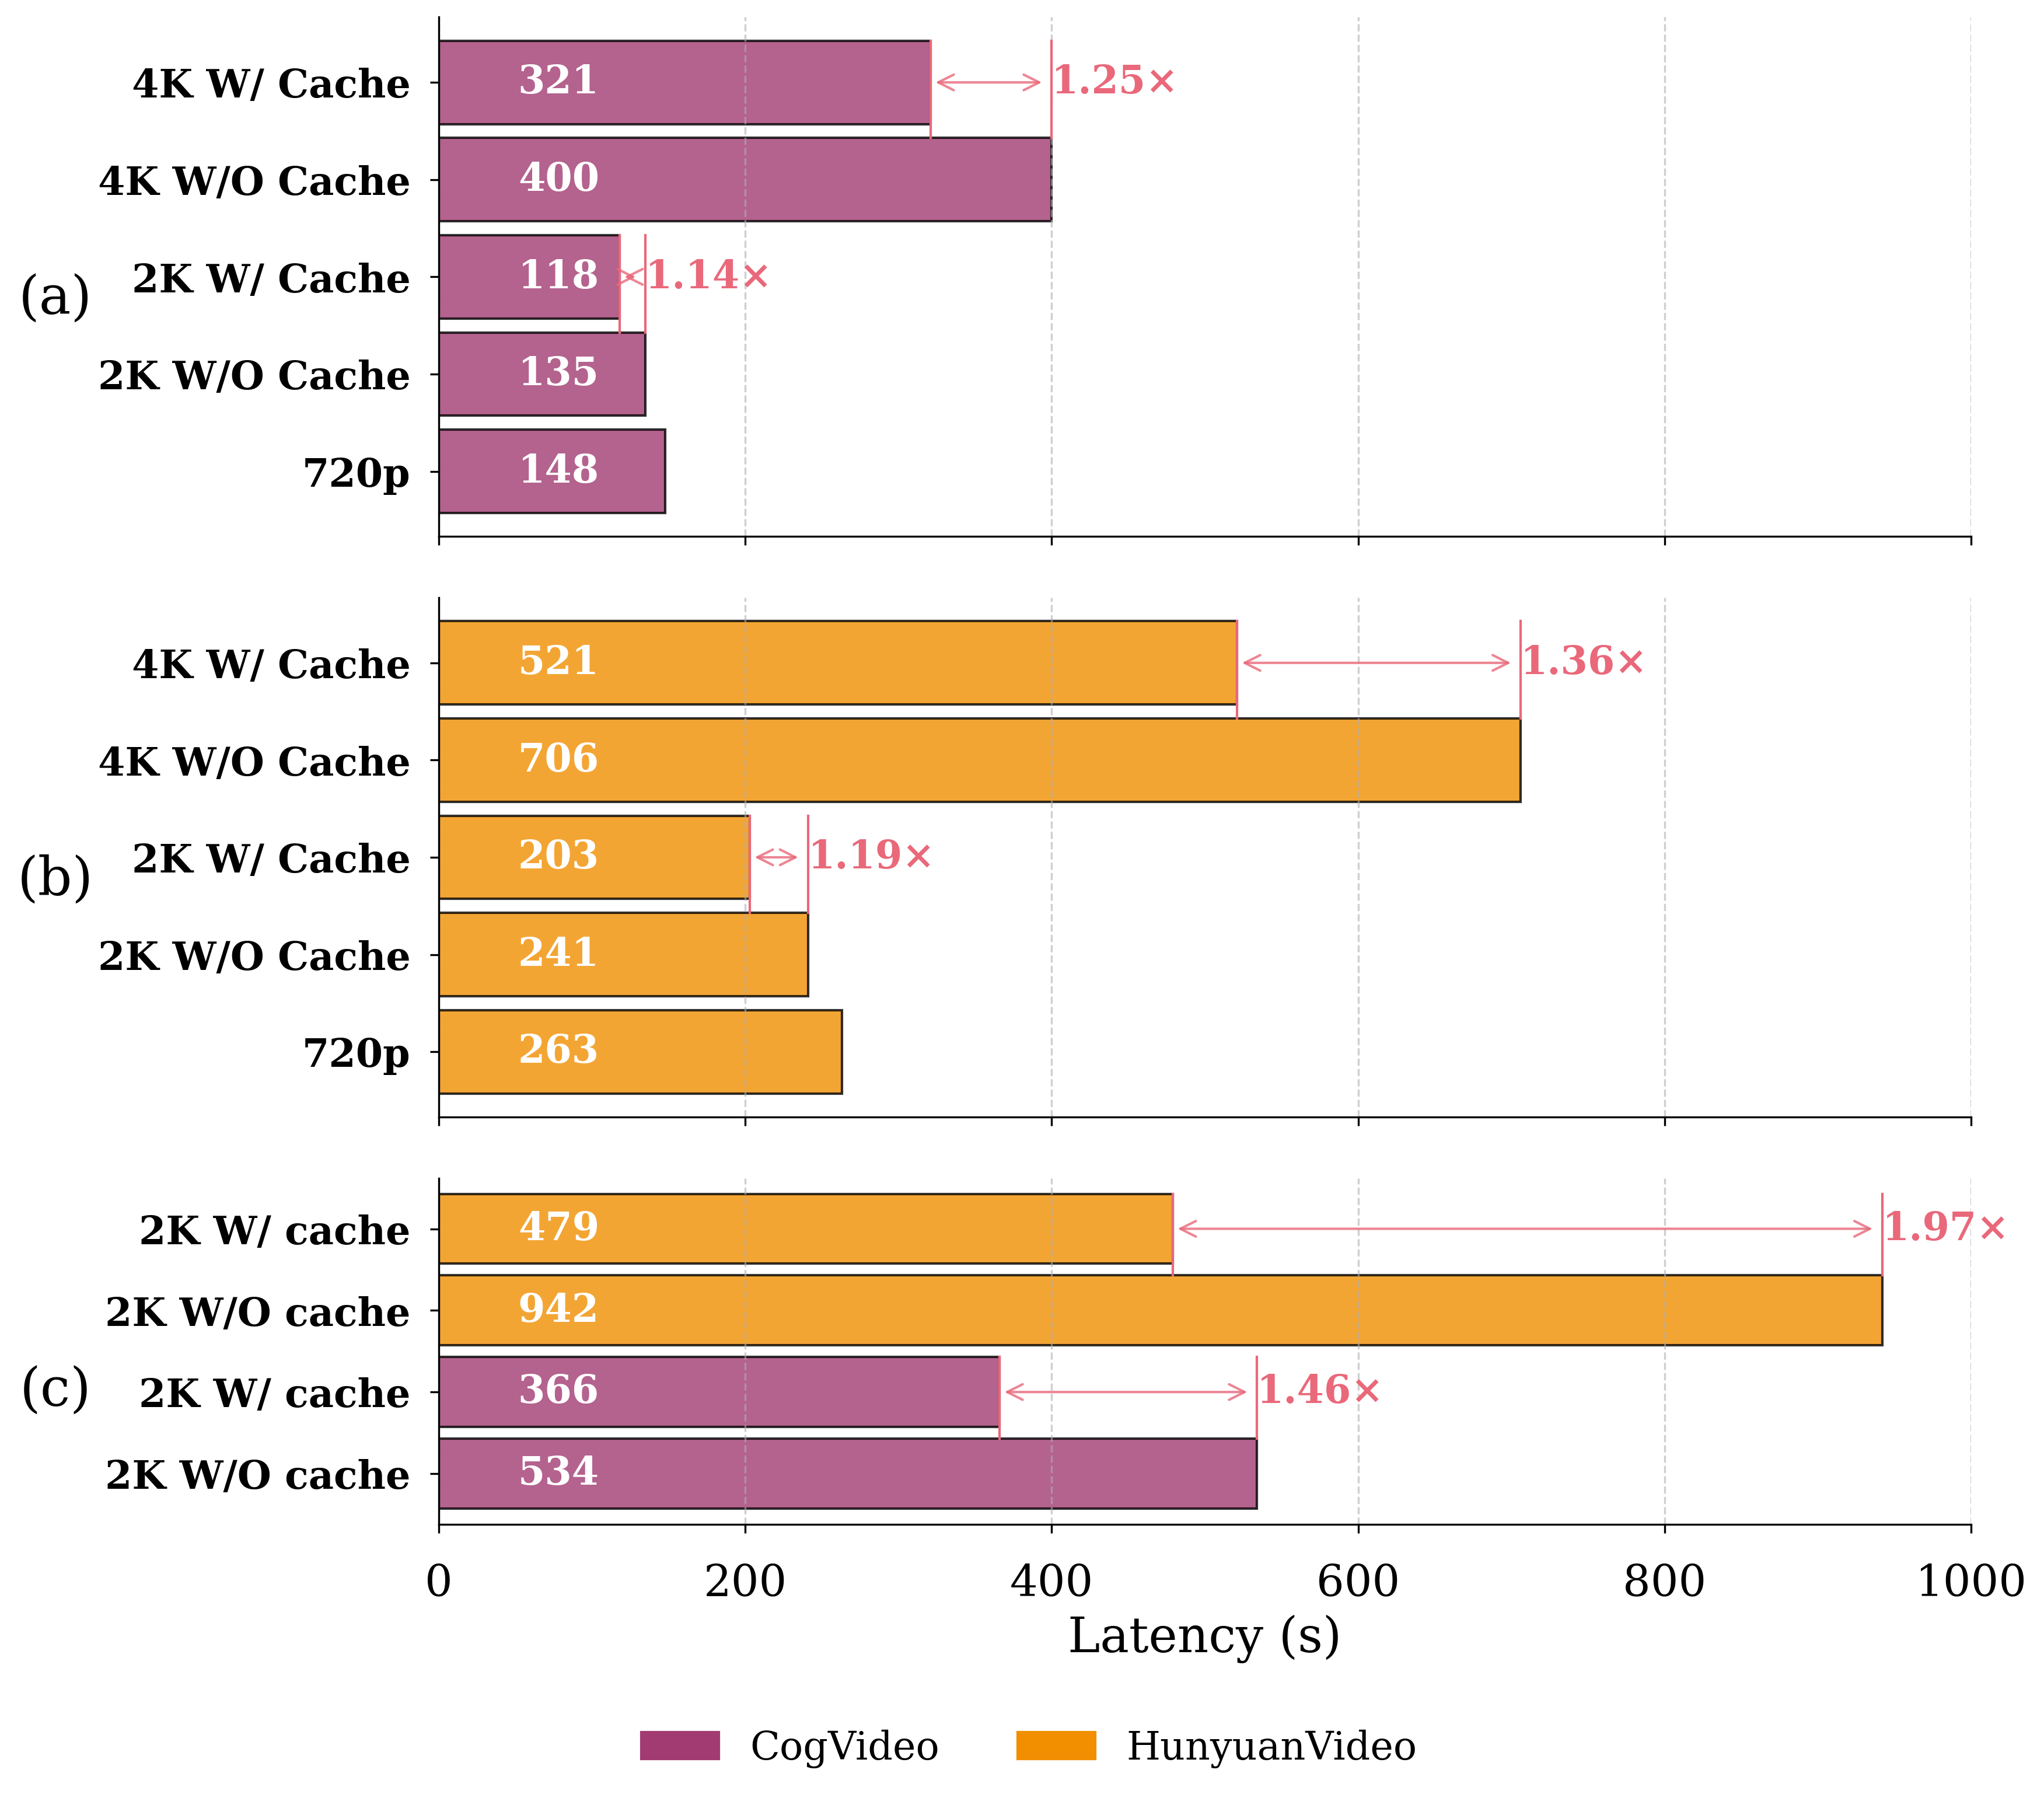

In [147]:
import matplotlib.pyplot as plt
import numpy as np

# Data
resolutions = ['720p', '2K W/O Cache', '2K W/ Cache', '4K W/O Cache', '4K W/ Cache']

cogvideo_latency = [148, 135, 118, 400, 321]
hunyuan_latency = [263, 241, 203, 706, 521]

cogvideo_1gpu_latency = [534, 366]  # [2K W/O, 2K W/]
hunyuan_1gpu_latency = [942, 479]   # [2K W/O, 2K W/]

# Create figure with 3 subplots: CogVideo, HunyuanVideo, and right GPU comparison
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [1.5, 1.5, 1]})

colors = ["#A23B72", "#F18F01"]

# --- Helper: speedup with dotted line from W/O -> W/ in horizontal ---
def annotate_speedup(ax, y_wo, x_wo, y_w, x_w, color='black', height=None, width=None):
    speedup = x_wo / x_w
    half_height = height / 2
    color = "#E9687A"
    # Vertical dotted line spanning from W/O bar right to W/ bar right
    ax.plot([x_wo, x_wo], [y_wo + half_height, y_w + half_height], linestyle='-', linewidth=1, color=color)
    ax.plot([x_w, x_w], [y_wo + half_height, y_w + half_height], linestyle='-', linewidth=1, color=color)
    # center_y = (y_wo + y_w) /
    # Arrow from that line left to the W/ cache bar end with label
    ax.annotate(f"{speedup:.2f}×",
                xy=(x_w, y_w),
                xytext=(x_wo, y_w),
                textcoords='data',
                ha='left', va='center', fontsize=16, color=color, fontweight='bold',
                arrowprops=dict(arrowstyle='<->', lw=1, color=color, alpha=0.8))

# --- CogVideo subplot ---
y = np.arange(0, 100, 0.7)[:len(resolutions)]
height = 0.6

bars1 = ax1.barh(y, cogvideo_latency, height, label='CogVideo', color=colors[0], edgecolor='black', linewidth=1, alpha=0.8)
ax1.set_yticks(y)
ax1.set_yticklabels(resolutions, fontsize=16, fontweight='bold')
# ax1.set_xlabel('Latency (ms)', loc="right")
ax1.set_title('(a)', x=-0.25, y=0.4)
ax1.set_xlim(0, 1000)
ax1.set_xticklabels([])

ax1.spines['right'].set_visible(False)
ax1.spines['top'].set_visible(False)
ax1.grid(True, axis='x', linestyle='--', alpha=0.6)

for bar in bars1:
    width = bar.get_width()
    ax1.annotate(f'{width}',
                 xy=(100, bar.get_y() + bar.get_height() / 2),
                 xytext=(3, 0),
                 textcoords="offset points",
                 ha='right', va='center', fontsize=16, color="white", fontweight='bold')

# Speedups for CogVideo (2K and 4K)
annotate_speedup(ax1, y_wo=y[1], x_wo=cogvideo_latency[1], y_w=y[2], x_w=cogvideo_latency[2], height=height)
annotate_speedup(ax1, y_wo=y[3], x_wo=cogvideo_latency[3], y_w=y[4], x_w=cogvideo_latency[4], height=height)

# --- HunyuanVideo subplot ---
y2 = np.arange(0, 100, 0.7)[:len(resolutions)]
bars2 = ax2.barh(y2, hunyuan_latency, height, label='HunyuanVideo', color=colors[1], edgecolor='black', linewidth=1, alpha=0.8)
ax2.set_yticks(y2)
ax2.set_yticklabels(resolutions, fontsize=16, fontweight='bold')
# ax2.set_xlabel('Latency (ms)', loc="right")
ax2.set_title('(b)', x=-0.25, y=0.4)
ax2.set_xlim(0, 1000)
ax2.set_xticklabels([])

ax2.spines['right'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax2.grid(True, axis='x', linestyle='--', alpha=0.6)

for bar in bars2:
    width = bar.get_width()
    ax2.annotate(f'{width}',
                 xy=(100, bar.get_y() + bar.get_height() / 2),
                 xytext=(3, 0),
                 textcoords="offset points",
                 ha='right', va='center', fontsize=16, color="white", fontweight='bold')

# Speedups for HunyuanVideo (2K and 4K)
annotate_speedup(ax2, y_wo=y2[1], x_wo=hunyuan_latency[1], y_w=y2[2], x_w=hunyuan_latency[2], height=height)
annotate_speedup(ax2, y_wo=y2[3], x_wo=hunyuan_latency[3], y_w=y2[4], x_w=hunyuan_latency[4], height=height)

# --- Right subplot (group by Model; bars = W/O vs W/) ---
models = ['CogVideo', 'HunyuanVideo']
yg = np.arange(0, 100, 0.7)[:4]
height3 = 0.6

bar3_y = yg[:2]
bar3_x = [cogvideo_1gpu_latency[0], cogvideo_1gpu_latency[1]]
bar4_y = yg[2:]
bar4_x = [hunyuan_1gpu_latency[0], hunyuan_1gpu_latency[1]]

bars3 = ax3.barh(bar3_y, bar3_x, height3, label='CogVideo', edgecolor='black', linewidth=1, alpha=0.8, color=colors[0])
bars4 = ax3.barh(bar4_y, bar4_x, height3, label='HunyuanVideo', edgecolor='black', linewidth=1, alpha=0.8, color=colors[1])

ax3.set_yticks(yg)
ax3.set_yticklabels(['2K W/O cache', '2K W/ cache'] * 2, fontsize=16, fontweight='bold')
ax3.set_xlabel('Latency (s)', loc="center")
ax3.set_title('(c)', x=-0.25, y=0.3)
ax3.set_xlim(0, 1000)

ax3.spines['right'].set_visible(False)
ax3.spines['top'].set_visible(False)
ax3.grid(True, axis='x', linestyle='--', alpha=0.6)

for bar in list(bars3) + list(bars4):
    width = bar.get_width()
    ax3.annotate(f'{width}',
                 xy=(100, bar.get_y() + bar.get_height() / 2),
                 xytext=(3, 0),
                 textcoords="offset points",
                 ha='right', va='center', fontsize=16, color="white", fontweight='bold')

# Speedups per model on the right subplot
annotate_speedup(ax3, y_wo=bar3_y[0], x_wo=bar3_x[0], y_w=bar3_y[1], x_w=bar3_x[1], height=height3)
annotate_speedup(ax3, y_wo=bar4_y[0], x_wo=bar4_x[0], y_w=bar4_y[1], x_w=bar4_x[1], height=height3)

import matplotlib.patches as mpatches
legend_patches = [mpatches.Patch(color=colors[i], label=models[i]) for i in range(len(models))]
fig.legend(handles=legend_patches, loc='lower center', bbox_to_anchor=(0.5, -0.05), 
           ncol=3, fontsize=16, frameon=False)

fig.savefig('latency_comparison_4GPUs.pdf', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

# Cache Ablation Study - 2D Heatmaps


In [29]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

# Cache ablation study data
data = {
    'Cache_Threshold': [0.05, 0.05, 0.05, 0.05, 0.05,
                       0.07, 0.07, 0.07, 0.07, 0.07,
                       0.09, 0.09, 0.09, 0.09, 0.09,
                       0.11, 0.11, 0.11, 0.11, 0.11,
                       0.13, 0.13, 0.13, 0.13, 0.13],
    'Scale': [0.1, 0.2, 0.3, 0.4, 0.5,
              0.1, 0.2, 0.3, 0.4, 0.5,
              0.1, 0.2, 0.3, 0.4, 0.5,
              0.1, 0.2, 0.3, 0.4, 0.5,
              0.1, 0.2, 0.3, 0.4, 0.5],
    'Avg_Quality': [83.328, 83.26, 83.174, 83.37, 83.368,
                    83.474, 83.156, 83.362, 83.312, 83.346,
                    83.444, 83.436, 83.314, 83.484, 83.234,
                    83.296, 83.384, 83.332, 83.358, 83.33,
                    83.51, 83.354, 83.048, 83.392, 83.4],
    'Latency': [135, 135, 132, 132, 129,
                129, 129, 129, 123, 120,
                123, 126, 114, 111, 108,
                114, 108, 114, 114, 99,
                117, 120, 105, 102, 102]
}

# Create DataFrame
df = pd.DataFrame(data)

# Create pivot tables for heatmaps
quality_pivot = df.pivot(index='Cache_Threshold', columns='Scale', values='Avg_Quality')
latency_pivot = df.pivot(index='Cache_Threshold', columns='Scale', values='Latency')

print("Quality Score Pivot Table:")
print(quality_pivot.round(2))
print("\nLatency Pivot Table:")
print(latency_pivot)


Quality Score Pivot Table:
Scale              0.1    0.2    0.3    0.4    0.5
Cache_Threshold                                   
0.05             83.33  83.26  83.17  83.37  83.37
0.07             83.47  83.16  83.36  83.31  83.35
0.09             83.44  83.44  83.31  83.48  83.23
0.11             83.30  83.38  83.33  83.36  83.33
0.13             83.51  83.35  83.05  83.39  83.40

Latency Pivot Table:
Scale            0.1  0.2  0.3  0.4  0.5
Cache_Threshold                         
0.05             135  135  132  132  129
0.07             129  129  129  123  120
0.09             123  126  114  111  108
0.11             114  108  114  114   99
0.13             117  120  105  102  102


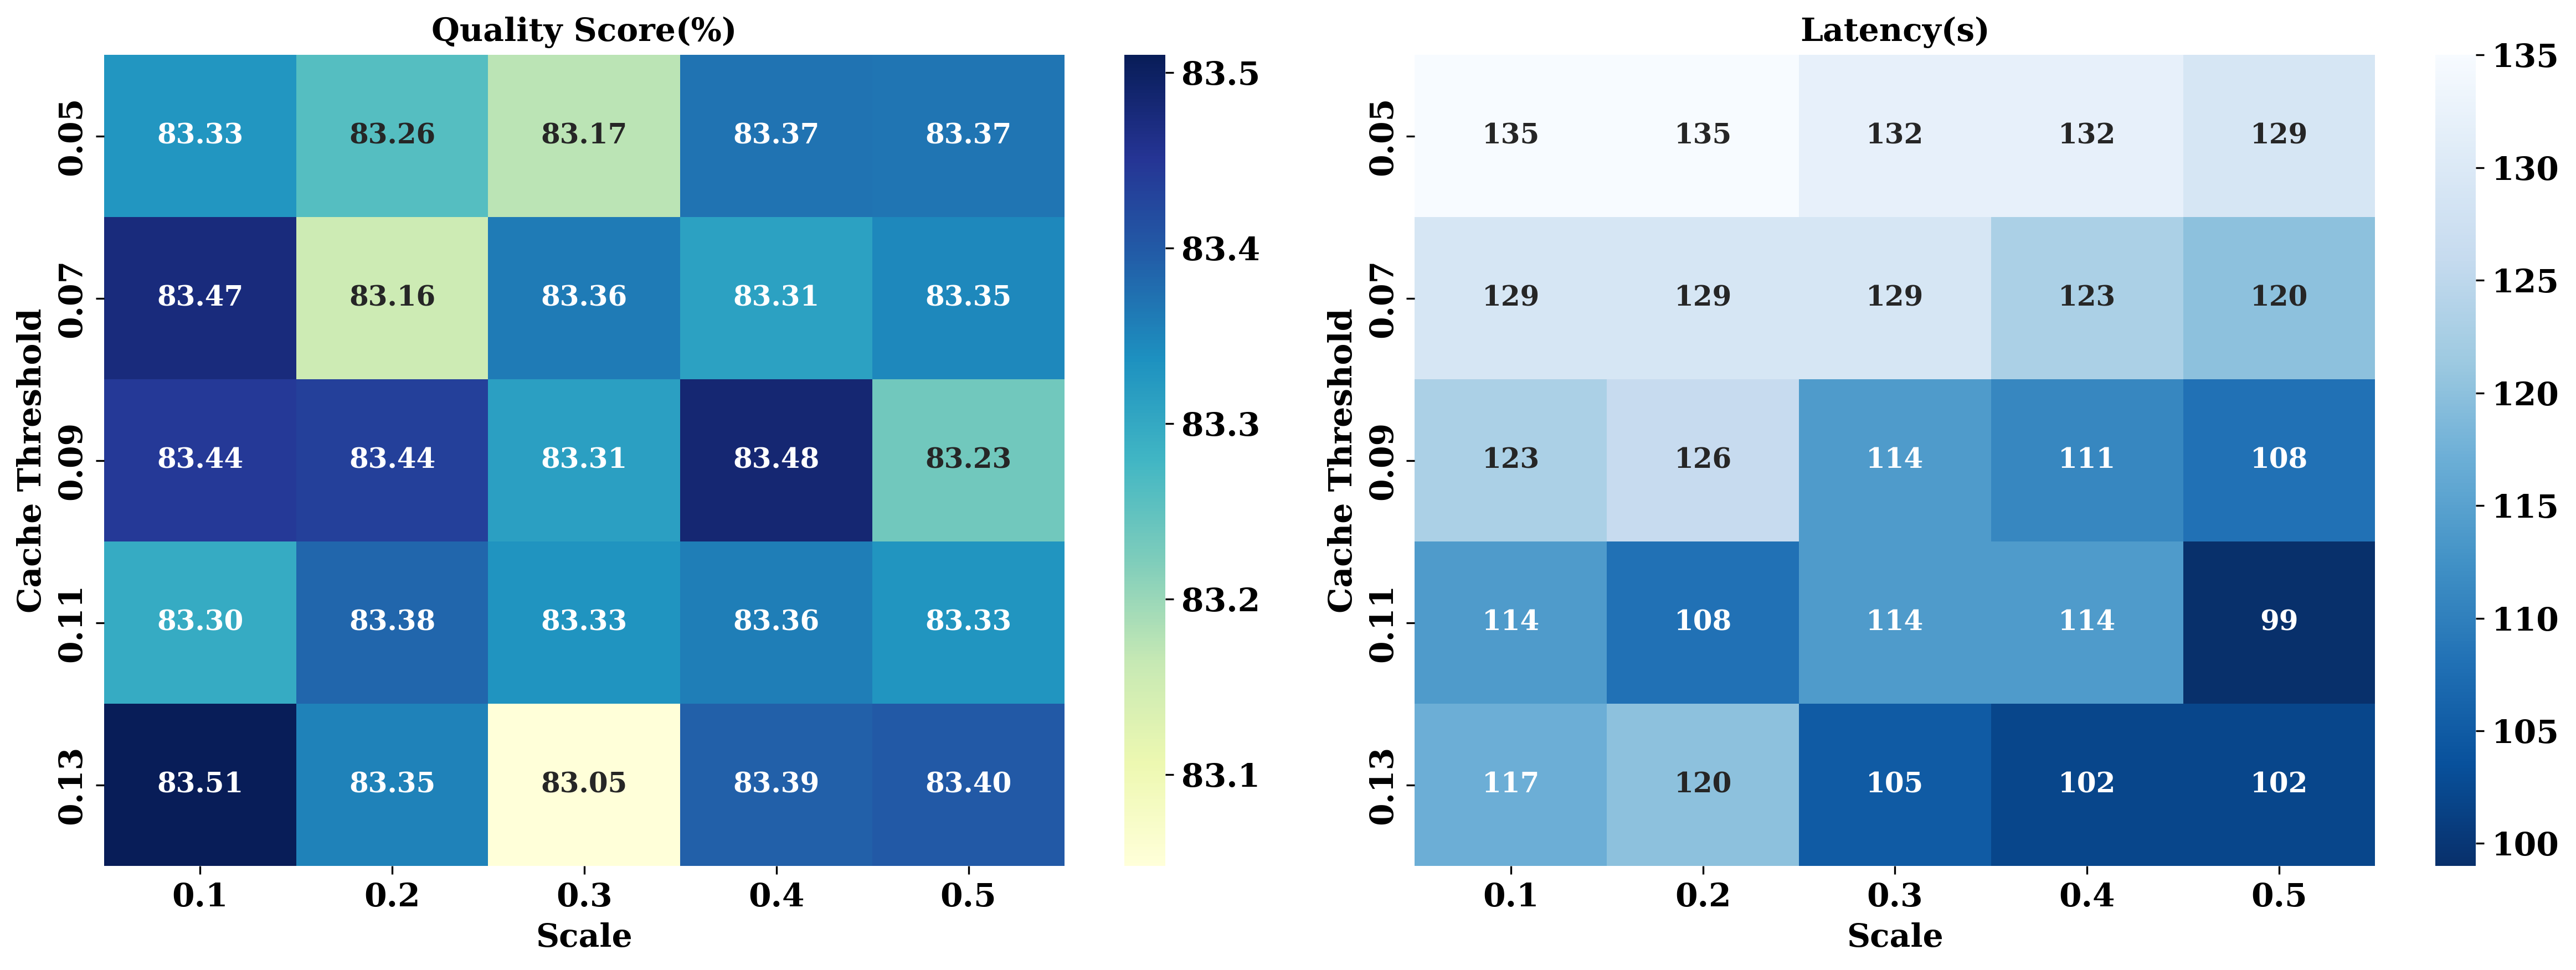

In [33]:
# 设置论文级别的绘图参数
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'font.family': 'serif',
    'text.usetex': False,
    'figure.dpi': 300,
    'font.weight': 'bold'  # 全局设置字体为粗体
})

# 创建包含两个子图的图表
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. Quality Score 热力图
sns.heatmap(quality_pivot, annot=True, fmt='.2f', cmap='YlGnBu', 
            ax=ax1, annot_kws={'weight': 'bold'})  # 热力图内数字粗体
ax1.set_title('Quality Score(%)', fontweight='bold')
ax1.set_xlabel('Scale', fontweight='bold')
ax1.set_ylabel('Cache Threshold', fontweight='bold')
# 设置坐标轴刻度标签为粗体
ax1.tick_params(axis='both', which='major', labelsize=14)
for label in ax1.get_xticklabels() + ax1.get_yticklabels():
    label.set_fontweight('bold')
# 设置colorbar的刻度标签为粗体
cbar1 = ax1.collections[0].colorbar
for label in cbar1.ax.get_yticklabels():
    label.set_fontweight('bold')

# 2. Latency 热力图
sns.heatmap(latency_pivot, annot=True, fmt='d', cmap='Blues_r', 
            ax=ax2, annot_kws={'weight': 'bold'})  # 热力图内数字粗体
ax2.set_title('Latency(s)', fontweight='bold')
ax2.set_xlabel('Scale', fontweight='bold')
ax2.set_ylabel('Cache Threshold', fontweight='bold')
# 设置坐标轴刻度标签为粗体
ax2.tick_params(axis='both', which='major', labelsize=14)
for label in ax2.get_xticklabels() + ax2.get_yticklabels():
    label.set_fontweight('bold')
# 设置colorbar的刻度标签为粗体
cbar2 = ax2.collections[0].colorbar
for label in cbar2.ax.get_yticklabels():
    label.set_fontweight('bold')

plt.tight_layout()
plt.show()

# 保存图片
fig.savefig('cache_ablation_heatmaps.pdf', dpi=300, bbox_inches='tight')


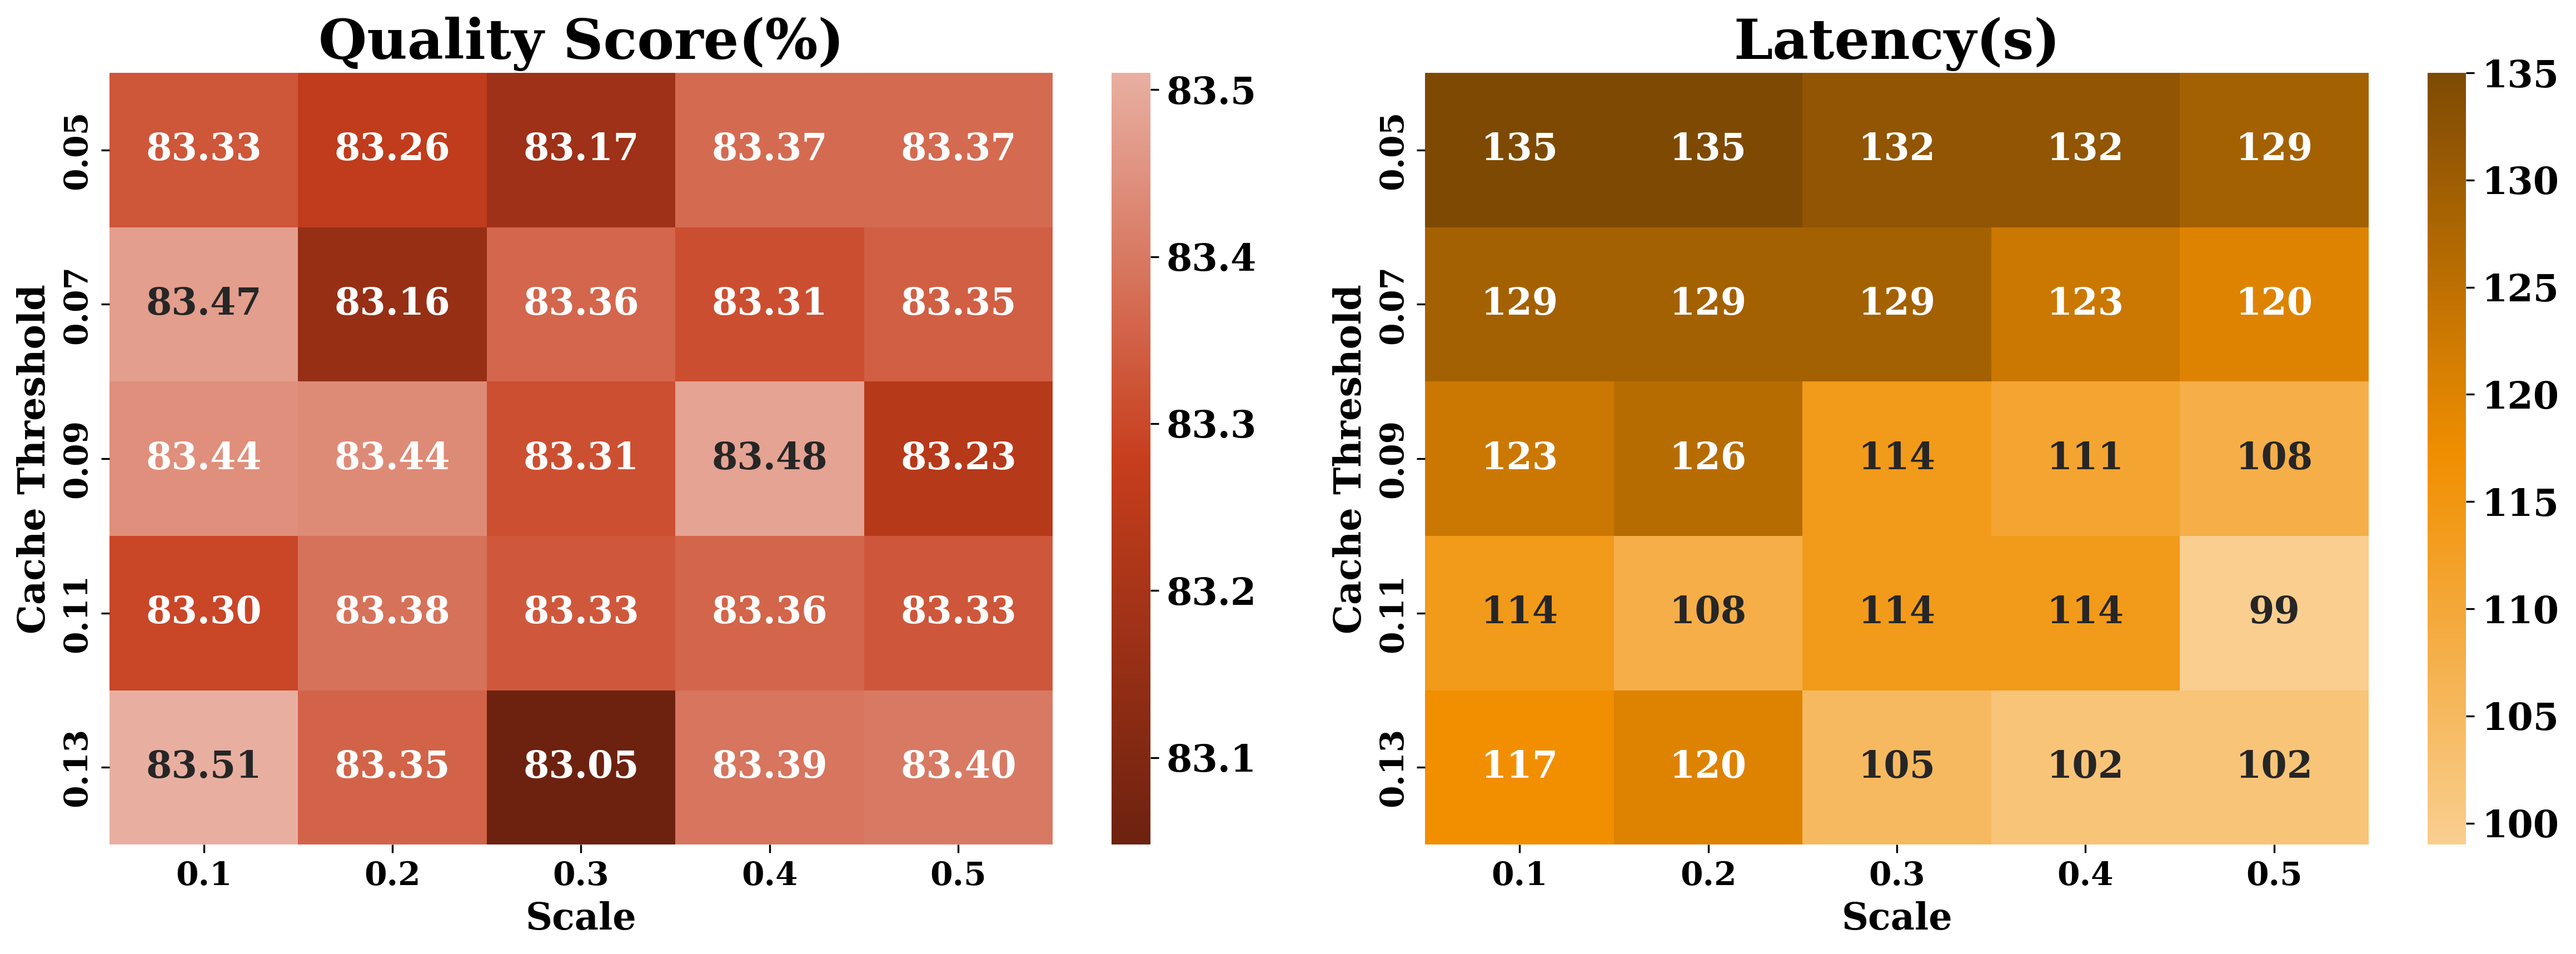

In [54]:
from matplotlib.colors import LinearSegmentedColormap

# 设置论文级别的绘图参数
plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 16,
    'axes.labelsize': 16,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 16,
    'font.family': 'serif',
    'text.usetex': False,
    'figure.dpi': 300,
    'font.weight': 'bold'  # 全局设置字体为粗体
})

cmap_purple = LinearSegmentedColormap.from_list(
    "purple_cmap", ["#6D220F", "#C73E1D", "#E8AFA1"]  # white → purple → black
)

cmap_orange = LinearSegmentedColormap.from_list(
    "orange_cmap", ["#F9CE8F", "#F18F01", "#7E4A03"]  # white → orange → black
)

# 创建包含两个子图的图表
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. Quality Score 热力图
sns.heatmap(quality_pivot, annot=True, fmt='.2f', cmap=cmap_purple, 
            ax=ax1, annot_kws={'weight': 'bold'})  # 热力图内数字粗体
ax1.set_title('Quality Score(%)', fontweight='bold', fontsize=24)
ax1.set_xlabel('Scale', fontweight='bold')
ax1.set_ylabel('Cache Threshold', fontweight='bold')
# 设置坐标轴刻度标签为粗体
ax1.tick_params(axis='both', which='major', labelsize=14)
for label in ax1.get_xticklabels() + ax1.get_yticklabels():
    label.set_fontweight('bold')
# 设置colorbar的刻度标签为粗体
cbar1 = ax1.collections[0].colorbar
for label in cbar1.ax.get_yticklabels():
    label.set_fontweight('bold')

# 2. Latency 热力图
sns.heatmap(latency_pivot, annot=True, fmt='d', cmap=cmap_orange, 
            ax=ax2, annot_kws={'weight': 'bold'})  # 热力图内数字粗体
ax2.set_title('Latency(s)', fontweight='bold', fontsize=24)
ax2.set_xlabel('Scale', fontweight='bold')
ax2.set_ylabel('Cache Threshold', fontweight='bold')
# 设置坐标轴刻度标签为粗体
ax2.tick_params(axis='both', which='major', labelsize=14)
for label in ax2.get_xticklabels() + ax2.get_yticklabels():
    label.set_fontweight('bold')
# 设置colorbar的刻度标签为粗体
cbar2 = ax2.collections[0].colorbar
for label in cbar2.ax.get_yticklabels():
    label.set_fontweight('bold')

plt.tight_layout()
plt.show()

# 保存图片
fig.savefig('cache_ablation_heatmaps.pdf', dpi=300, bbox_inches='tight')

In [4]:
# 分析最佳配置
print("=== Cache Ablation Analysis ===\n")

# 找出最高质量分数
max_quality_idx = quality_pivot.values.argmax()
max_quality_row, max_quality_col = np.unravel_index(max_quality_idx, quality_pivot.shape)
max_quality_threshold = quality_pivot.index[max_quality_row]
max_quality_scale = quality_pivot.columns[max_quality_col]
max_quality_score = quality_pivot.iloc[max_quality_row, max_quality_col]
max_quality_latency = latency_pivot.iloc[max_quality_row, max_quality_col]

print(f"Highest Quality Configuration:")
print(f"  Cache Threshold: {max_quality_threshold}")
print(f"  Scale: {max_quality_scale}")
print(f"  Quality Score: {max_quality_score:.3f}")
print(f"  Latency: {max_quality_latency}s")

# 找出最低延迟
min_latency_idx = latency_pivot.values.argmin()
min_latency_row, min_latency_col = np.unravel_index(min_latency_idx, latency_pivot.shape)
min_latency_threshold = latency_pivot.index[min_latency_row]
min_latency_scale = latency_pivot.columns[min_latency_col]
min_latency_value = latency_pivot.iloc[min_latency_row, min_latency_col]
min_latency_quality = quality_pivot.iloc[min_latency_row, min_latency_col]

print(f"\nLowest Latency Configuration:")
print(f"  Cache Threshold: {min_latency_threshold}")
print(f"  Scale: {min_latency_scale}")
print(f"  Latency: {min_latency_value}s")
print(f"  Quality Score: {min_latency_quality:.3f}")

# 计算质量-延迟的权衡
print(f"\nQuality-Latency Trade-off:")
print(f"  Quality difference: {max_quality_score - min_latency_quality:.3f}")
print(f"  Latency difference: {max_quality_latency - min_latency_value}s")

# 寻找平衡点（质量>83.3 且延迟<115）
balanced_configs = []
for i, threshold in enumerate(quality_pivot.index):
    for j, scale in enumerate(quality_pivot.columns):
        quality = quality_pivot.iloc[i, j]
        latency = latency_pivot.iloc[i, j]
        if quality > 83.3 and latency < 115:
            balanced_configs.append((threshold, scale, quality, latency))

print(f"\nBalanced Configurations (Quality > 83.3, Latency < 115s):")
for config in balanced_configs:
    print(f"  Threshold: {config[0]}, Scale: {config[1]}, Quality: {config[2]:.3f}, Latency: {config[3]}s")


=== Cache Ablation Analysis ===

Highest Quality Configuration:
  Cache Threshold: 0.13
  Scale: 0.1
  Quality Score: 83.510
  Latency: 117s

Lowest Latency Configuration:
  Cache Threshold: 0.11
  Scale: 0.5
  Latency: 99s
  Quality Score: 83.330

Quality-Latency Trade-off:
  Quality difference: 0.180
  Latency difference: 18s

Balanced Configurations (Quality > 83.3, Latency < 115s):
  Threshold: 0.09, Scale: 0.3, Quality: 83.314, Latency: 114s
  Threshold: 0.09, Scale: 0.4, Quality: 83.484, Latency: 111s
  Threshold: 0.11, Scale: 0.2, Quality: 83.384, Latency: 108s
  Threshold: 0.11, Scale: 0.3, Quality: 83.332, Latency: 114s
  Threshold: 0.11, Scale: 0.4, Quality: 83.358, Latency: 114s
  Threshold: 0.11, Scale: 0.5, Quality: 83.330, Latency: 99s
  Threshold: 0.13, Scale: 0.4, Quality: 83.392, Latency: 102s
  Threshold: 0.13, Scale: 0.5, Quality: 83.400, Latency: 102s


# Number of gpus, parallelism, latency comparsion

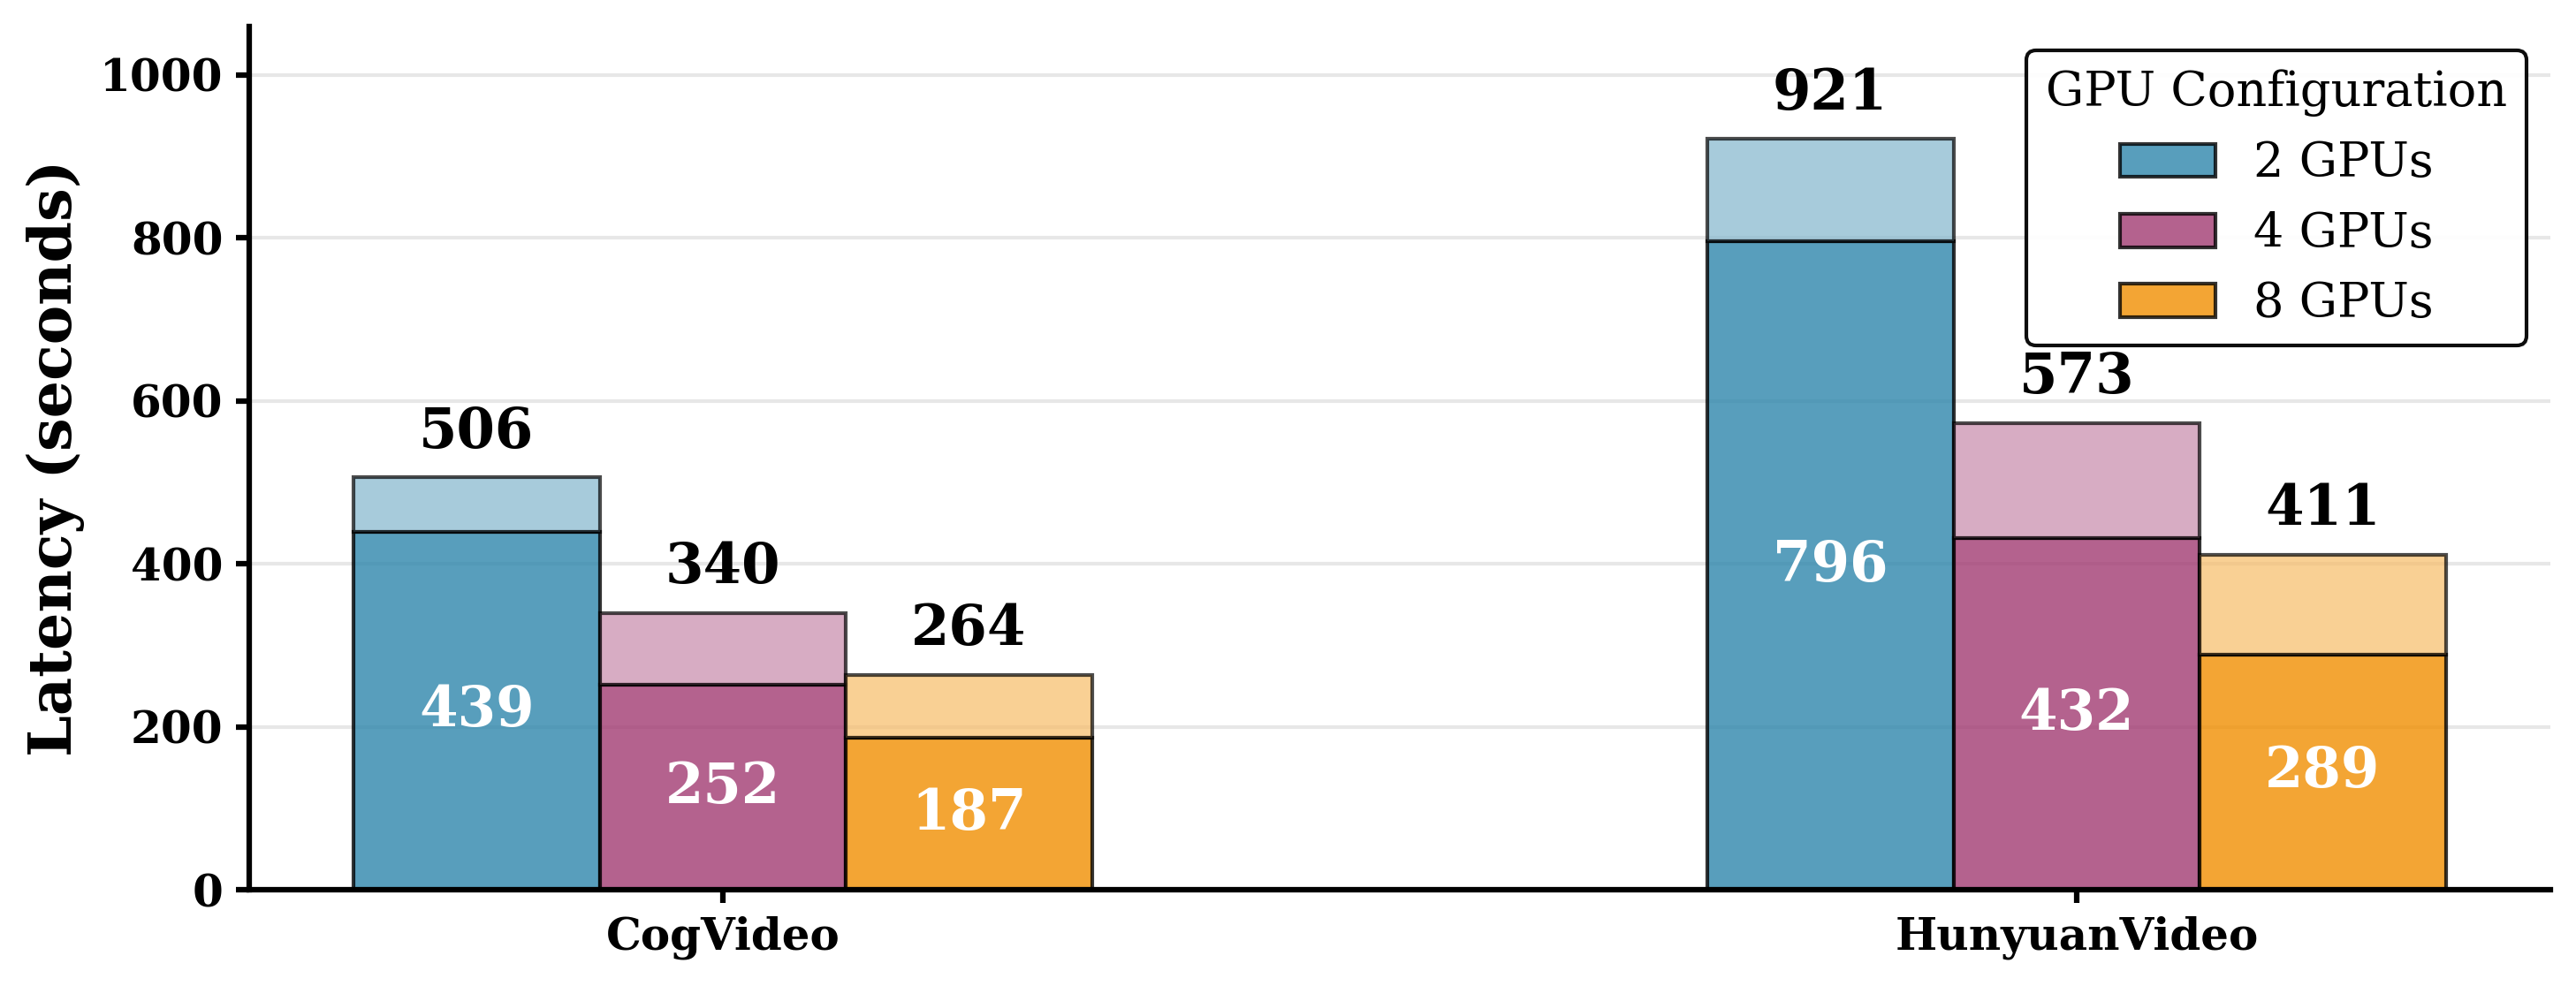

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# 设置matplotlib参数以适配LaTeX论文
plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 20,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 16,
    'font.family': 'serif',
    'text.usetex': False,  # 如果系统有LaTeX可以设为True
    'figure.dpi': 300
})

# CogVideo数据 - 带workload stealing优化的延迟（当前实际性能）- 只保留4K
cogvideo_data = {
    '2 GPUs': 439,
    '4 GPUs': 252,
    '8 GPUs': 187
}

# CogVideo没有workload stealing优化时的额外延迟（优化带来的提升）
cogvideo_additional_cost = {
    '2 GPUs': 506-439,
    '4 GPUs': 340-252,
    '8 GPUs': 264-187
}

# Hunyuan数据 - 带workload stealing优化的延迟（当前实际性能）- 只保留4K
hunyuan_data = {
    '2 GPUs': 796,
    '4 GPUs': 432,
    '8 GPUs': 289
}

# Hunyuan没有workload stealing优化时的额外延迟（优化带来的提升）
hunyuan_additional_cost = {
    '2 GPUs': 921-796,
    '4 GPUs': 573-432,
    '8 GPUs': 411-289
}

# 准备数据用于绘图 - 现在数据结构是直接的字典，不是嵌套的
all_gpu_configs = list(cogvideo_data.keys())
all_gpu_configs.sort(key=lambda x: int(x.split()[0]))  # 按GPU数量排序

# 创建单个图表
fig, ax = plt.subplots(1, 1, figsize=(10, 4))

# 设置分组柱状图的参数
models = ['CogVideo', 'HunyuanVideo']
n_models = len(models)
n_gpu_configs = len(all_gpu_configs)
bar_width = 0.04  # 柱子宽度
model_spacing = 0.1  # 两个模型之间的间距

# 颜色设置 - 为每种GPU配置使用不同颜色
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']
gpu_colors = {config: colors[i % len(colors)] for i, config in enumerate(all_gpu_configs)}

# 为优化前的额外成本创建浅色版本
def lighten_color(color, factor=0.4):
    """将颜色变浅"""
    import matplotlib.colors as mcolors
    rgb = mcolors.hex2color(color)
    # 混合白色来变浅
    light_rgb = tuple(c + (1 - c) * factor for c in rgb)
    return mcolors.to_hex(light_rgb)

gpu_colors_light = {config: lighten_color(color) for config, color in gpu_colors.items()}

# 绘制柱状图
model_data = [
    (cogvideo_data, cogvideo_additional_cost, 'CogVideo'),
    (hunyuan_data, hunyuan_additional_cost, 'HunyuanVideo')
]

x_positions = []
model_centers = []
added_to_legend = set()  # 跟踪已添加到图例的GPU配置

for model_idx, (data, additional_cost_data, model_name) in enumerate(model_data):
    # 计算当前模型的起始位置
    model_start = model_idx * (n_gpu_configs * bar_width + model_spacing)
    
    # 计算当前模型的中心位置
    model_center = model_start + (n_gpu_configs - 1) * bar_width / 2
    model_centers.append(model_center)
    
    # 为当前模型的每个GPU配置绘制柱状图
    for gpu_idx, gpu_config in enumerate(all_gpu_configs):
        x_pos = model_start + gpu_idx * bar_width
        
        if model_idx == 0:  # 只在第一个模型时记录x位置用于图例
            x_positions.append(x_pos)
        
        optimized_value = data[gpu_config]
        additional_cost = additional_cost_data[gpu_config]
        total_value = optimized_value + additional_cost
        
        # 绘制优化后的性能（底层，深色）
        # 只为每个GPU配置添加一次图例标签
        show_label = gpu_config not in added_to_legend
        bar1 = ax.bar(x_pos, optimized_value, bar_width, 
                     label=f'{gpu_config} (Optimized)' if show_label else "",
                     color=gpu_colors[gpu_config], 
                     alpha=0.8, 
                     edgecolor='black', 
                     linewidth=1)
        
        # 绘制优化前的额外成本（上层，浅色）
        bar2 = ax.bar(x_pos, additional_cost, bar_width, 
                     bottom=optimized_value,
                     label=f'{gpu_config} (Additional Cost)' if show_label else "",
                     color=gpu_colors_light[gpu_config], 
                     alpha=0.7, 
                     edgecolor='black', 
                     linewidth=1)
        
        if show_label:
            added_to_legend.add(gpu_config)
        
        # 添加总数值标签
        ax.annotate(f'{total_value}',
                   xy=(x_pos, total_value),
                   xytext=(0, 5),
                   textcoords="offset points",
                   ha='center', va='bottom',
                   fontsize=15, fontweight='bold')
        
        # 添加优化后数值标签（在底部柱状图中间）
        ax.annotate(f'{optimized_value}',
                   xy=(x_pos, optimized_value/2),
                   xytext=(0, 0),
                   textcoords="offset points",
                   ha='center', va='center',
                   fontsize=15, fontweight='bold',
                   color='white')

# 设置坐标轴标签和标题
# ax.set_xlabel('Models', fontsize=16, fontweight='bold')
ax.set_ylabel('Latency (seconds)', fontsize=16, fontweight='bold')
# ax.set_title('4K Resolution - Multi-GPU Latency Comparison with Workload Stealing Optimization', fontsize=18, fontweight='bold')

# 设置x轴刻度和标签
ax.set_xticks(model_centers)
ax.set_xticklabels(models, fontsize=16, fontweight='bold')

# 添加图例，只显示GPU配置
handles, labels = ax.get_legend_handles_labels()
# 只显示GPU配置的数量，不显示优化状态（避免图例过于复杂）
simplified_handles = []
simplified_labels = []
for handle, label in zip(handles, labels):
    if '(Optimized)' in label:
        gpu_config = label.split(' (Optimized)')[0]
        simplified_handles.append(handle)
        simplified_labels.append(gpu_config)

legend = ax.legend(simplified_handles, simplified_labels, 
                  fontsize=13, 
                  loc='upper right',
                  framealpha=0.95, 
                  edgecolor='black',
                  title='GPU Configuration',
                  title_fontsize=13)

# 设置网格
ax.grid(True, alpha=0.3, axis='y', linewidth=1)
ax.set_axisbelow(True)

# 设置坐标轴样式
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

# 设置坐标轴刻度样式
ax.tick_params(axis='both', labelsize=12, width=1.5)
for label in ax.get_yticklabels():
    label.set_fontweight('bold')

# 调整y轴范围，确保所有数值都能清楚显示（包括额外成本）
all_optimized_values = list(cogvideo_data.values()) + list(hunyuan_data.values())
all_additional_costs = list(cogvideo_additional_cost.values()) + list(hunyuan_additional_cost.values())
all_total_values = [opt + add for opt, add in zip(all_optimized_values, all_additional_costs)]
y_max = max(all_total_values)
ax.set_ylim(0, y_max * 1.15)

# 调整布局
plt.tight_layout()

# 保存图表
plt.savefig('multimodel_multiGPU_latency_4k_comparison.pdf', format='pdf', bbox_inches='tight', 
            dpi=300, facecolor='white', edgecolor='none')

# 显示图表
plt.show()




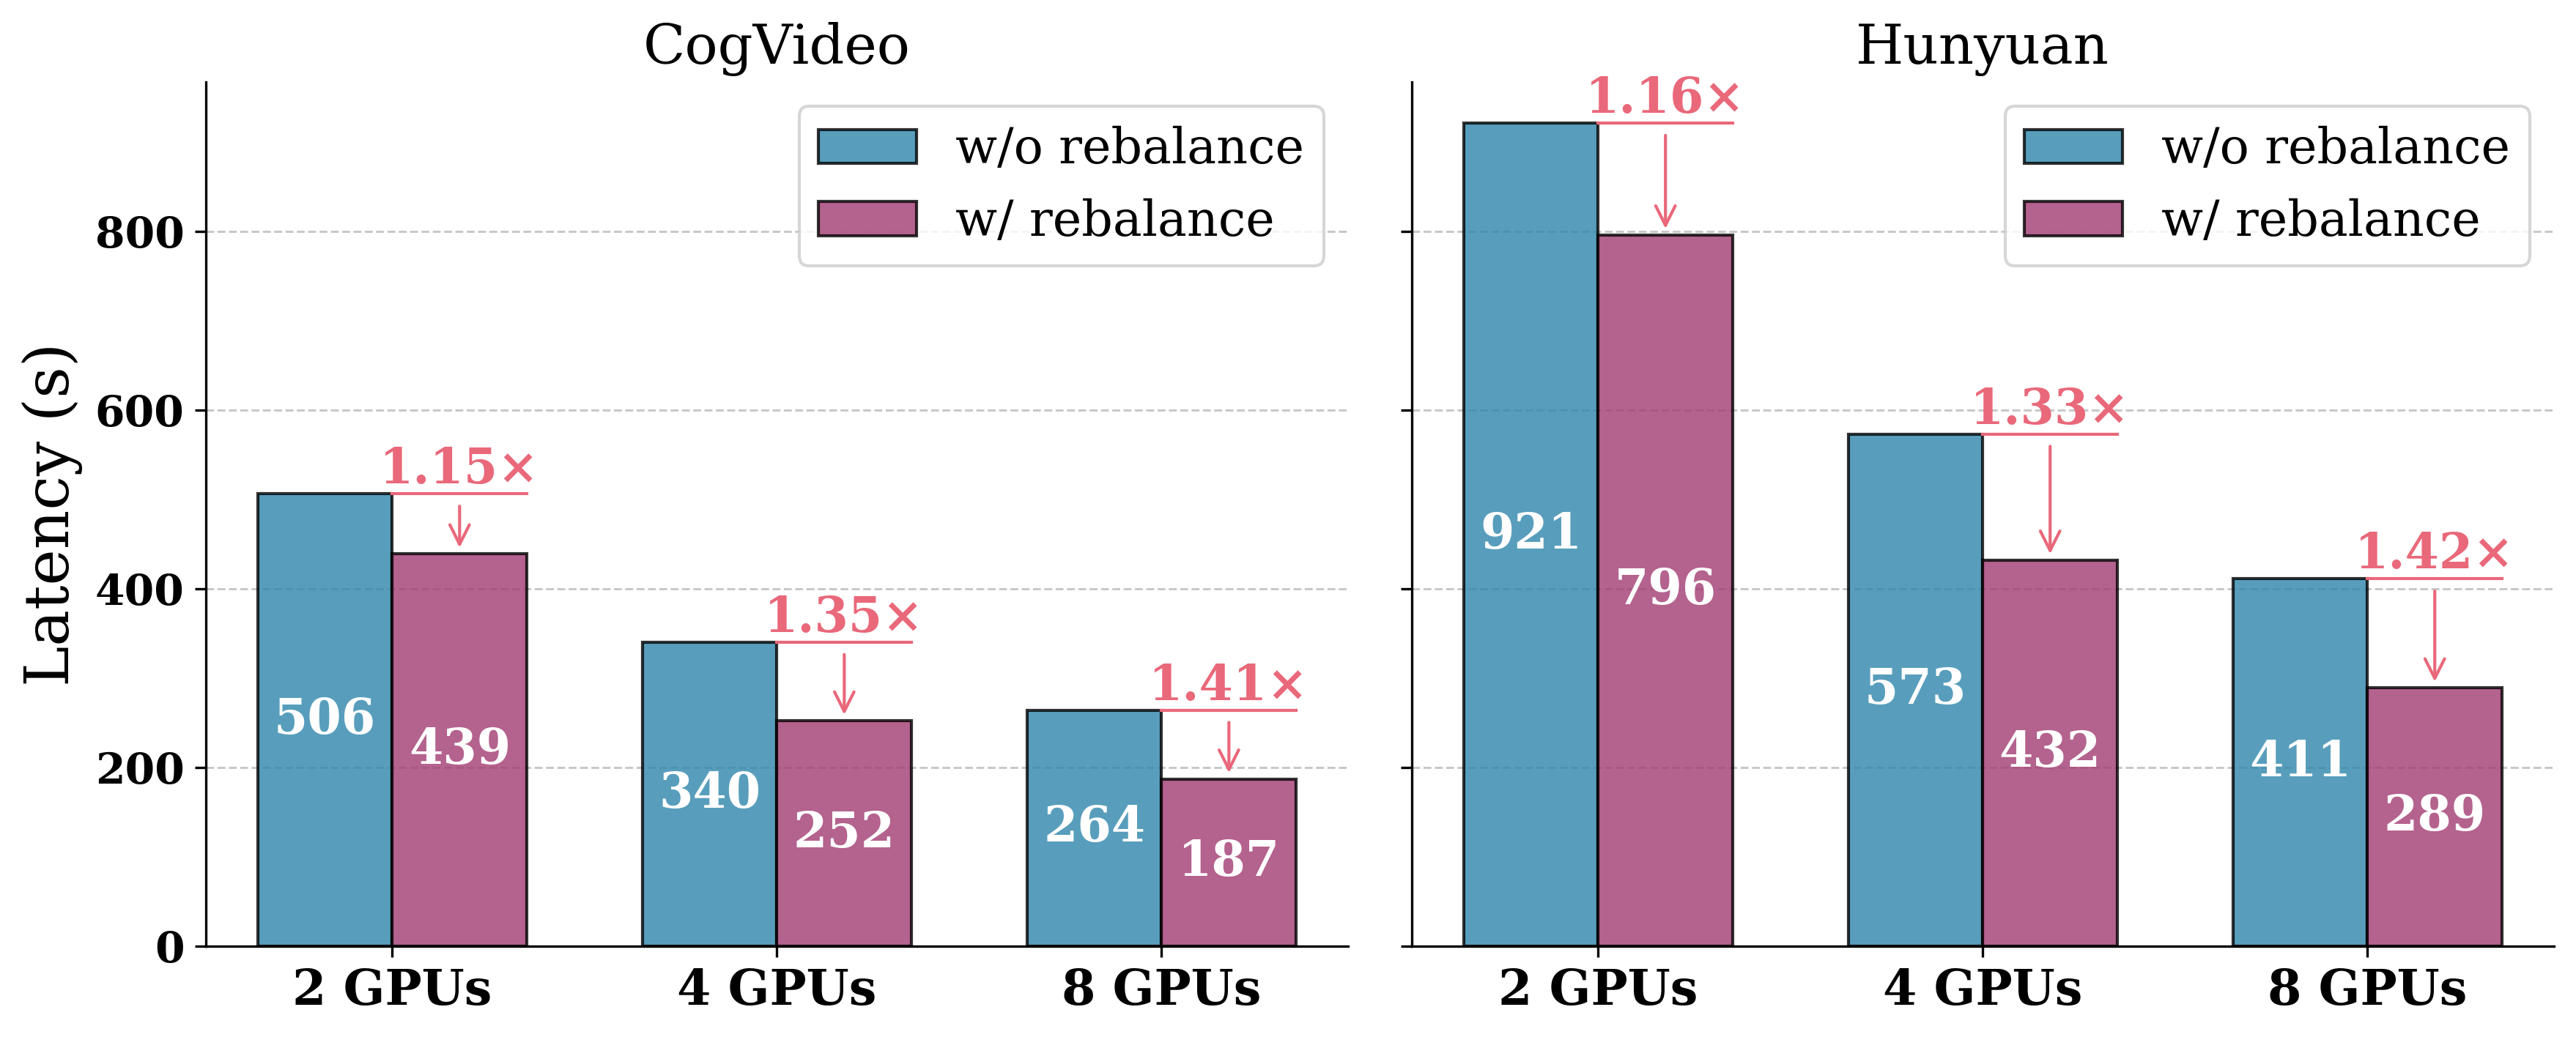

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# 设置matplotlib参数以适配LaTeX论文
plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 20,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 16,
    'font.family': 'serif',
    'text.usetex': False,  # 如果系统有LaTeX可以设为True
    'figure.dpi': 300
})

cogvideo_optimized_cost = {
    '2 GPUs': 439,
    '4 GPUs': 252,
    '8 GPUs': 187
}

cogvideo_all_cost = {
    '2 GPUs': 506,
    '4 GPUs': 340,
    '8 GPUs': 264,
}

hunyuan_optimized_cost = {
    '2 GPUs': 796,
    '4 GPUs': 432,
    '8 GPUs': 289
}

hunyuan_all_cost = {
    '2 GPUs': 921,
    '4 GPUs': 573,
    '8 GPUs': 411,
}

colors = ["#2E86AB", "#A23B72"]

# --- Helper: speedup with dotted line from W/O -> above W/ and arrow to W/ top ---
def annotate_speedup(ax, x_wo, y_wo, x_w, y_w, color='red', width=None):
    """Draw a horizontal dotted line from the W/O cache bar top to above the W/ cache bar,
    then an arrow from that line to the top of the W/ cache bar, and label the speedup."""
    speedup = y_wo / y_w
    half_width = width / 2
    color="#E9687A"
    # Horizontal dotted line spanning from W/O bar top to above the W/ bar
    ax.plot([x_wo + half_width, x_w + half_width], [y_wo, y_wo], linestyle='-', linewidth=1, color=color)
    # ax.plot([x_wo + half_width, x_w + half_width], [y_w, y_w], linestyle='-', linewidth=1, color=color)
    # center_x = (x_wo + x_w) / 2
    # Arrow from that line down to the W/ cache bar top with label
    ax.annotate(f"{speedup:.2f}×",
                xy=(x_w, y_w),            # arrow tip at W/ bar top
                xytext=(x_w, y_wo),       # start on the dotted line above W/
                textcoords='data',
                ha='center', va='bottom', fontsize=16, color=color, fontweight='bold',
                arrowprops=dict(arrowstyle='->', lw=1, color=color))

# GPU labels
labels = list(cogvideo_optimized_cost.keys())
x = np.arange(len(labels))  # positions for groups
bar_width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Function to draw bars with annotations
def plot_bars(ax, all_vals, opt_vals, title, colors):
    x_all = x - bar_width/2
    x_opt = x + bar_width/2
    bars_all = ax.bar(x_all, all_vals, bar_width, color=colors[0], label='w/o rebalance', edgecolor="black", alpha=0.8)
    bars_opt = ax.bar(x_opt, opt_vals, bar_width, color=colors[1], label='w/ rebalance', edgecolor="black", alpha=0.8)

    ax.set_title(title, loc="center")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=16, fontweight="bold")

    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Add horizontal gridlines
    ax.yaxis.grid(True, linestyle='--', linewidth=0.7, alpha=0.7)
    ax.set_axisbelow(True)

    # Annotate values inside bars
    for bar in bars_all + bars_opt:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height * 0.5,
            f'{height}',
            ha='center', va='center', color='white', fontsize=16, fontweight="bold",
        )

    ax.legend()

    ax.tick_params(axis='y', labelsize=14)
    for label in ax.get_yticklabels():
        label.set_fontweight('bold')

    # annotate speedup
    for i in range(3):
        annotate_speedup(
            ax,
            x_wo=x_all[i],
            x_w=x_opt[i],
            y_wo=all_vals[i],
            y_w=opt_vals[i],
            width=bar_width,
        )
    
    # for i in range(1, 3):
    #     annotate_speedup(
    #         ax,
    #         x_wo=x_all[0],
    #         x_w=x_all[i],
    #         y_wo=all_vals[0],
    #         y_w=all_vals[i],
    #         width=(x_all[1] - x_all[0])*i,
    #     )

# --- CogVideo subplot ---
plot_bars(axes[0], list(cogvideo_all_cost.values()), list(cogvideo_optimized_cost.values()), "CogVideo", colors)
axes[0].set_ylabel("Latency (s)")

# --- Hunyuan subplot ---
plot_bars(axes[1], list(hunyuan_all_cost.values()), list(hunyuan_optimized_cost.values()), "Hunyuan", colors)

plt.tight_layout()
plt.savefig('multimodel_multiGPU_latency_4k_comparison.pdf', format='pdf', bbox_inches='tight', 
            dpi=300, facecolor='white', edgecolor='none')
plt.show()

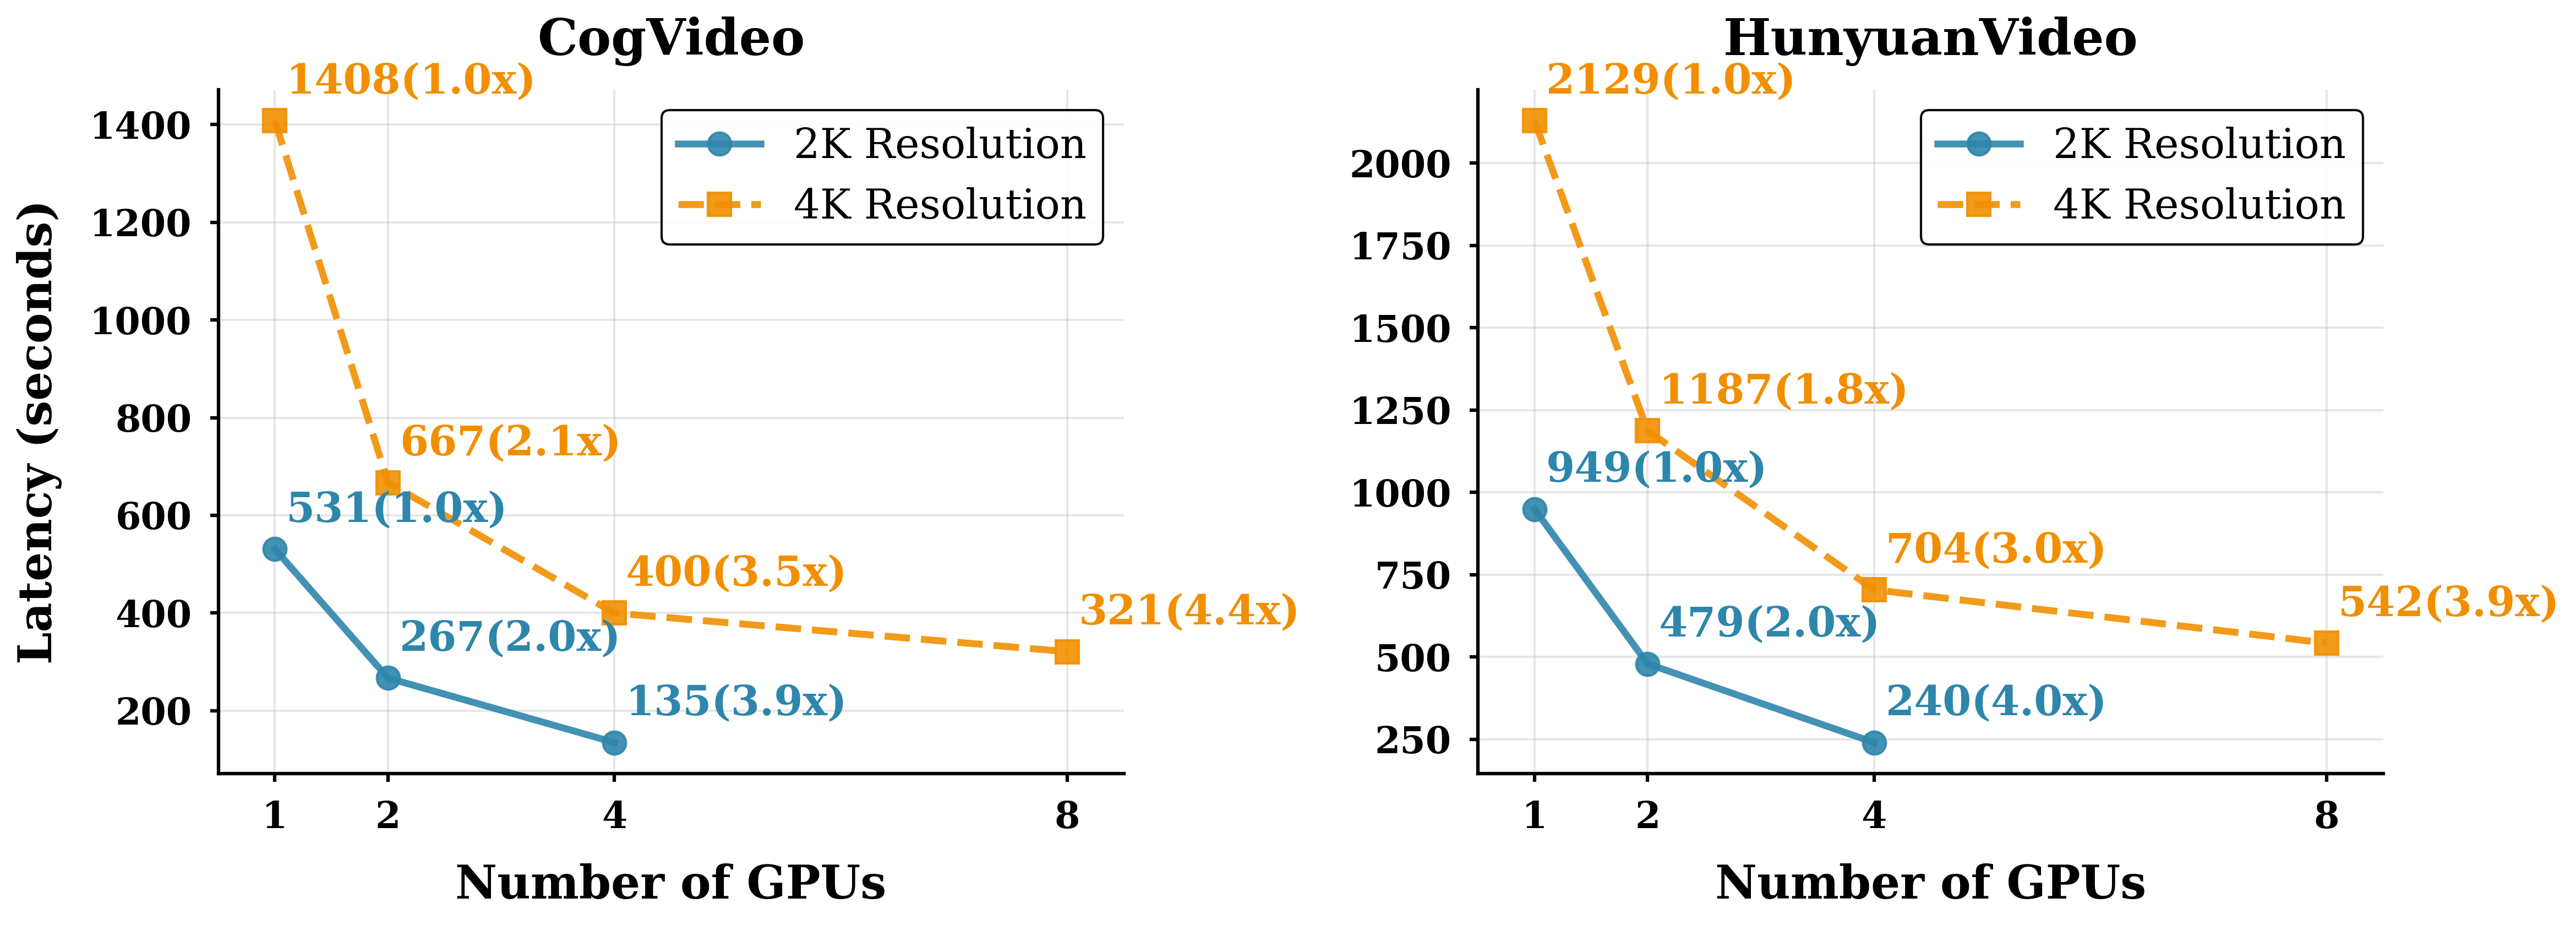

In [173]:
## GPU Scalability - Line Plot
import matplotlib.pyplot as plt
import numpy as np

# 设置matplotlib参数以适配LaTeX论文 - 增大字体和间距
plt.rcParams.update({
    'font.size': 20,           # 从16增加到20
    'axes.titlesize': 22,      # 从18增加到22
    'axes.labelsize': 20,      # 从16增加到20
    'xtick.labelsize': 18,     # 从14增加到18
    'ytick.labelsize': 18,     # 从14增加到18
    'legend.fontsize': 16,     # 从14增加到16
    'font.family': 'serif',
    'text.usetex': False,
    'figure.dpi': 300,
    'xtick.major.pad': 12,     # 增加x轴刻度与标签的距离
    'ytick.major.pad': 8,      # 增加y轴刻度与标签的距离
})

cogvideo_data = {
    "2K": {  # 4 tiles
        "1 GPU": 531,
        "2 GPUs": 267,
        "4 GPUs": 135,
    },
    "4K": {  # 9 tiles
        "1 GPU": 1408,
        "2 GPUs": 667,
        "4 GPUs": 400,
        "8 GPUs": 321,
    },
}

hunyuan_data = {
    "2K": {  # 4 tiles
        "1 GPU": 949,
        "2 GPUs": 479,
        "4 GPUs": 240,
    },
    "4K": {  # 9 tiles
        "1 GPU": 2129,
        "2 GPUs": 1187,
        "4 GPUs": 704,
        "8 GPUs": 542,
    },
}

# 处理数据，提取GPU数量和对应的延迟
def extract_scalability_data(data):
    """提取可扩展性数据：GPU数量 vs 延迟"""
    scalability_data = {}
    
    for resolution in ['2K', '4K']:
        gpu_counts = []
        latencies = []
        
        if resolution in data:
            # 按GPU数量排序
            gpu_configs = sorted(data[resolution].keys(), key=lambda x: int(x.split()[0]))
            
            for gpu_config in gpu_configs:
                gpu_count = int(gpu_config.split()[0])
                latency = data[resolution][gpu_config]
                
                gpu_counts.append(gpu_count)
                latencies.append(latency)
        
        scalability_data[resolution] = {
            'gpu_counts': gpu_counts,
            'latencies': latencies
        }
    
    return scalability_data

# 提取CogVideo和Hunyuan的可扩展性数据
cogvideo_scalability = extract_scalability_data(cogvideo_data)
hunyuan_scalability = extract_scalability_data(hunyuan_data)

# 创建一行两列的子图 - 增大图形尺寸
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))  # 从(14, 5)增加到(16, 6)

# 定义线条样式和颜色
line_styles = {
    '2K': {'color': '#2E86AB', 'linestyle': '-', 'marker': 'o'},
    '4K': {'color': '#F18F01', 'linestyle': '--', 'marker': 's'}
}

def plot_scalability(ax, scalability_data, model_name, show_ylabel=True):
    """绘制可扩展性折线图"""
    
    for resolution in ['2K', '4K']:
        if resolution in scalability_data:
            gpu_counts = scalability_data[resolution]['gpu_counts']
            latencies = scalability_data[resolution]['latencies']
            
            style = line_styles[resolution]
            
            # 绘制延迟线
            ax.plot(gpu_counts, latencies, 
                   color=style['color'], 
                   linestyle=style['linestyle'],
                   marker=style['marker'],
                   markersize=10,              # 从8增加到10
                   linewidth=3,                # 从2.5增加到3
                   label=f'{resolution} Resolution',
                   alpha=0.9)
            
            # 添加数值标签 - 增大字体
            for i, (gpu_count, latency) in enumerate(zip(gpu_counts, latencies)):
                speedup = latencies[0] / latency
                ax.annotate(f'{latency}({speedup:.1f}x)', 
                           xy=(gpu_count, latency),
                           xytext=(5, 12),          # 从(5, 10)增加到(5, 12)
                           textcoords='offset points',
                           fontsize=18,             # 从11增加到14
                           fontweight='bold',
                           color=style['color'])
    
    # 设置坐标轴 - 增大字体和间距
    ax.set_xlabel('Number of GPUs', fontsize=20, fontweight='bold', labelpad=12)  # 增加字体和间距
    if show_ylabel:
        ax.set_ylabel('Latency (seconds)', fontsize=20, fontweight='bold', labelpad=12)  # 增加字体和间距
    ax.set_title(f'{model_name}', fontsize=22, fontweight='bold', pad=15)  # 增加字体和间距
    
    # 设置x轴刻度
    all_gpu_counts = []
    for res_data in scalability_data.values():
        all_gpu_counts.extend(res_data['gpu_counts'])
    if all_gpu_counts:
        ax.set_xticks(sorted(set(all_gpu_counts)))
        ax.set_xlim(min(all_gpu_counts) - 0.5, max(all_gpu_counts) + 0.5)
    
    # 添加图例 - 增大字体
    ax.legend(fontsize=18, loc='upper right', framealpha=0.95, edgecolor='black')  # 从12增加到16
    
    # 设置网格
    ax.grid(True, alpha=0.3, linewidth=1)
    ax.set_axisbelow(True)
    
    # 设置坐标轴样式
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    
    # 设置坐标轴刻度样式 - 增大字体和间距
    ax.tick_params(axis='both', labelsize=16, width=1.5, pad=8)  # 从12增加到16，增加pad
    for label in ax.get_yticklabels():
        label.set_fontweight('bold')
    for label in ax.get_xticklabels():
        label.set_fontweight('bold')

# 绘制CogVideo可扩展性图（显示y轴标签）
plot_scalability(ax1, cogvideo_scalability, 'CogVideo', show_ylabel=True)

# 绘制Hunyuan可扩展性图（不显示y轴标签）
plot_scalability(ax2, hunyuan_scalability, 'HunyuanVideo', show_ylabel=False)

# 调整子图间距
plt.subplots_adjust(wspace=0.25)

# 调整布局
plt.tight_layout()

# 保存图表
plt.savefig('GPU_scalability_comparison.pdf', format='pdf', bbox_inches='tight', 
            dpi=300, facecolor='white', edgecolor='none')

# 显示图表
plt.show()

# E2E latency comparison

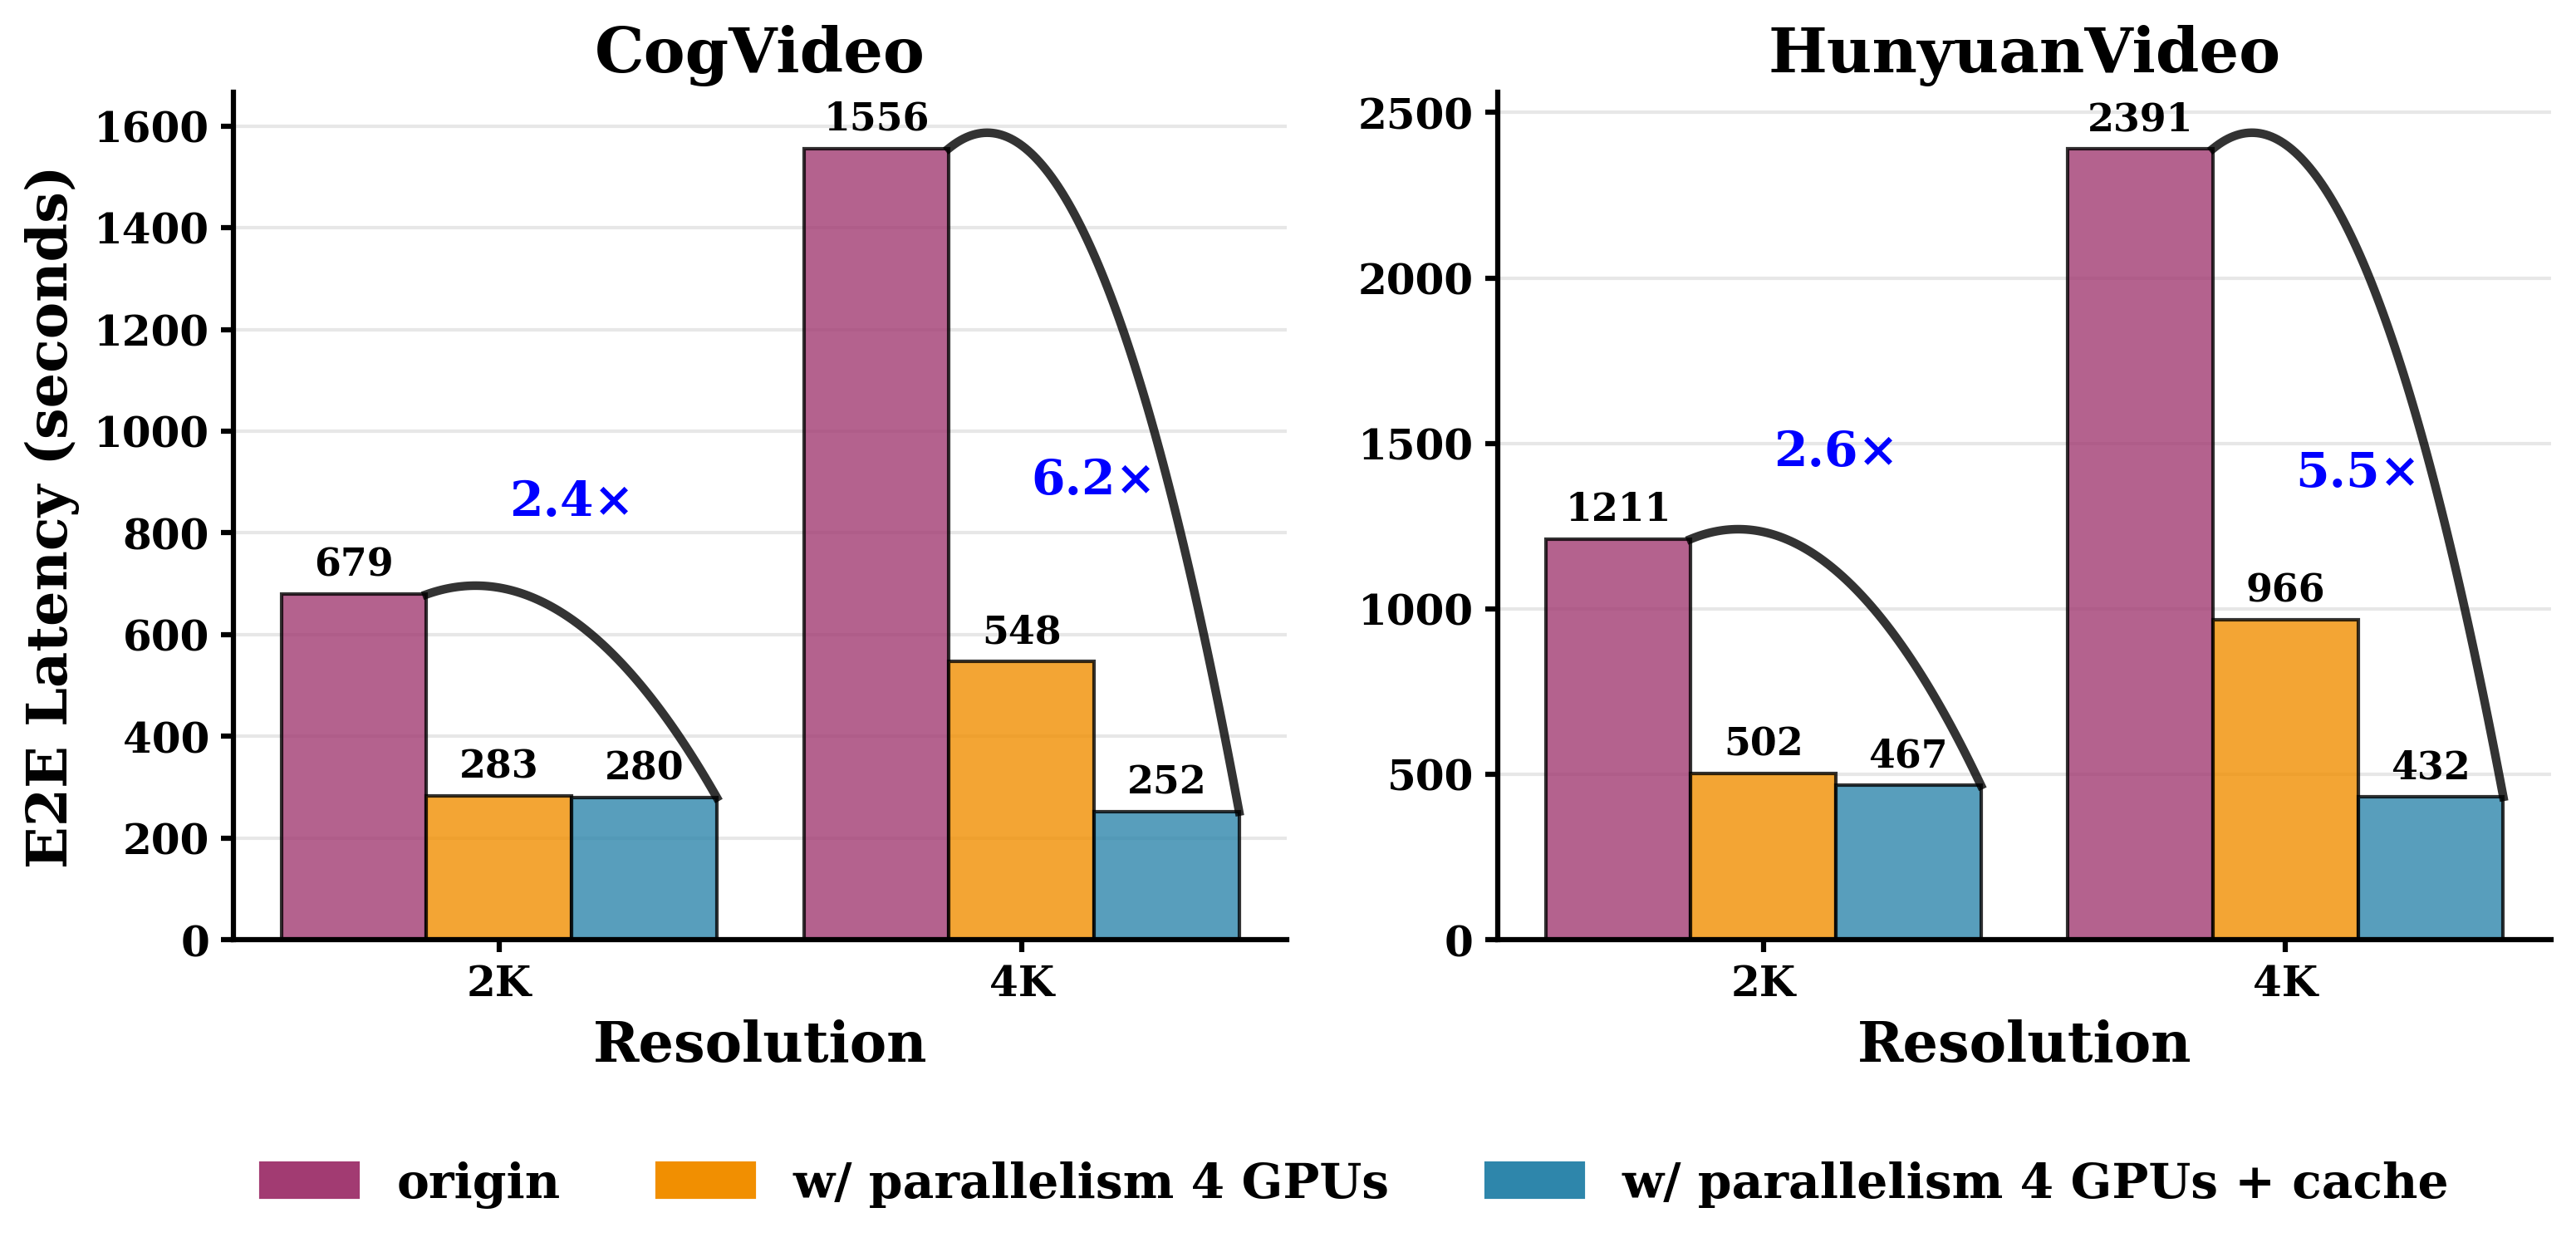

In [69]:
# Plot the E2E latency comparison
import matplotlib.pyplot as plt
import numpy as np

# 设置matplotlib参数以适配LaTeX论文
plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'font.family': 'serif',
    'text.usetex': False,
    'figure.dpi': 300
})

# 根据用户提供的E2E性能数据
# Cogvideo数据：每个数字代表总的E2E时间
cogvideo_e2e_data = {
    '2K': {
        'origin': 679, # 1 gpu, no cache
        'w/ parallelism 4 GPUs': 283, # no cache, 4 gpus
        'w/ parallelism 4 GPUs + cache': 280 # cache + 4gpus + reallocation
    },
    '4K': {
        'origin': 1556, 
        'w/ parallelism 4 GPUs': 548,
        'w/ parallelism 4 GPUs + cache': 252
    }
}

# HunyuanVideo数据：每个数字代表总的E2E时间
hunyuan_e2e_data = {
    '2K': {
        'origin': 1211,
        'w/ parallelism 4 GPUs': 502,
        'w/ parallelism 4 GPUs + cache': 467 # cache + 4gpus + reallocation
    },
    '4K': {
        'origin': 2391,
        'w/ parallelism 4 GPUs': 966,
        'w/ parallelism 4 GPUs + cache': 432
    }
}

# 创建一行两列的子图布局
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 设置柱状图参数
categories = ['origin', 'w/ parallelism 4 GPUs', 'w/ parallelism 4 GPUs + cache']
resolutions = ['2K', '4K']
n_categories = len(categories)
n_resolutions = len(resolutions)

# 为每个分辨率组设置位置
group_width = 0.5  # 每组的总宽度
bar_width = group_width / n_categories  # 每个柱子的宽度
group_spacing = 0.1  # 组间距 - 减少2K和4K之间的空白

# 颜色设置 - 为每种优化方法设置不同颜色
colors = ['#A23B72', '#F18F01', '#2E86AB']  # 红色，蓝色，绿色
# A23B72

def plot_model_comparison(ax, data, model_name, show_ylabel=True):
    """绘制单个模型的E2E性能比较"""
    
    # 计算每组的中心位置
    group_positions = np.arange(n_resolutions) * (group_width + group_spacing)
    
    # 存储每个柱子的位置和高度，用于后续绘制曲线
    bar_positions = {}
    bar_heights = {}
    
    # 为每个优化方法绘制柱状图
    for i, category in enumerate(categories):
        # 提取当前优化方法在所有分辨率下的数据
        values = [data[res][category] for res in resolutions]
        
        # 计算当前柱子的位置
        positions = group_positions + (i - (n_categories - 1) / 2) * bar_width
        
        # 存储位置和高度信息
        bar_positions[category] = positions
        bar_heights[category] = values
        
        # 绘制柱状图
        bars = ax.bar(positions, values, bar_width,  # 移除间隙，让柱子紧密相邻
                     label=category,
                     color=colors[i],
                     alpha=0.8,
                     edgecolor='black',
                     linewidth=1)
        
        # 添加数值标签
        for bar, value in zip(bars, values):
            height = bar.get_height()
            ax.annotate(f'{value}',
                       xy=(bar.get_x() + bar.get_width() / 2, height),
                       xytext=(0, 3),
                       textcoords="offset points",
                       ha='center', va='bottom',
                       fontsize=11, fontweight='bold')
    
    # 绘制从Origin到W/ Parallelism + Cache的曲线和加速倍数标注
    origin_positions = bar_positions['origin']
    cache_positions = bar_positions['w/ parallelism 4 GPUs + cache']
    origin_heights = bar_heights['origin']
    cache_heights = bar_heights['w/ parallelism 4 GPUs + cache']
    
    for i, res in enumerate(resolutions):
        # 计算加速倍数
        speedup = origin_heights[i] / cache_heights[i]
        
        # 获取起点和终点的位置
        x1 = origin_positions[i] + bar_width / 2  # Origin柱子的中心
        y1 = origin_heights[i]
        x2 = cache_positions[i] + bar_width / 2   # Cache柱子的中心
        y2 = cache_heights[i]
        
        # 绘制曲线（使用二次贝塞尔曲线效果）
        # 控制点在两个柱子中间偏上的位置
        control_x = (x1 + x2) / 2
        control_y = max(y1, y2) + max(y1, y2) * 0.15  # 控制点在较高柱子上方15%处
        
        # 创建曲线路径
        t = np.linspace(0, 1, 100)
        curve_x = (1-t)**2 * x1 + 2*(1-t)*t * control_x + t**2 * x2
        curve_y = (1-t)**2 * y1 + 2*(1-t)*t * control_y + t**2 * y2
        
        # 绘制曲线
        ax.plot(curve_x, curve_y, color='#000000', linewidth=2.5, alpha=0.8)
        
        # 根据分辨率决定加速倍数文本位置：2K在曲线上方，4K在曲线下方
        text_x = control_x
        if res == '2K':
            text_y = control_y + 80  # 2K在曲线上方
        else:  # 4K
            # 4K放在两个柱子之间的中等高度，确保可见
            text_y = (y1 + y2) / 2  # 在两个柱子的平均高度
        

        
        ax.annotate(f'{speedup:.1f}×',
                   xy=(text_x, text_y),
                   ha='center', va='center',
                   fontsize=14, fontweight='bold',
                   color='blue',
                   zorder=10)  # 确保在最前面显示
    
    # 设置标签和标题
    ax.set_xlabel('Resolution', fontsize=16, fontweight='bold')
    if show_ylabel:
        ax.set_ylabel('E2E Latency (seconds)', fontsize=16, fontweight='bold')
    ax.set_title(f'{model_name}', fontsize=18, fontweight='bold')
    
    # 设置x轴刻度和标签
    ax.set_xticks(group_positions)
    ax.set_xticklabels(resolutions, fontsize=14, fontweight='bold')
    
    # 不在子图中添加图例，稍后添加全局图例
    
    # 设置网格
    ax.grid(True, alpha=0.3, axis='y', linewidth=1)
    ax.set_axisbelow(True)
    
    # 设置坐标轴样式
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    
    # 设置坐标轴刻度样式
    ax.tick_params(axis='both', labelsize=12, width=1.5)
    for label in ax.get_yticklabels():
        label.set_fontweight('bold')

# 绘制Cogvideo子图（显示y轴标签）
plot_model_comparison(ax1, cogvideo_e2e_data, 'CogVideo', show_ylabel=True)

# 绘制HunyuanVideo子图（不显示y轴标签）
plot_model_comparison(ax2, hunyuan_e2e_data, 'HunyuanVideo', show_ylabel=False)

# 添加共用的全局图例在底部中央，一行三个，移除框框
# 创建正确的图例句柄，确保颜色与柱状图一致
import matplotlib.patches as mpatches
legend_patches = [mpatches.Patch(color=colors[i], label=categories[i]) for i in range(len(categories))]
fig.legend(handles=legend_patches, loc='lower center', bbox_to_anchor=(0.5, -0.05), 
           ncol=3, fontsize=14, frameon=False)

# 调整布局，为底部图例留出空间 - 增加10的padding
plt.subplots_adjust(bottom=0.20)

# 保存图表
plt.savefig('e2e_performance_comparison.pdf', format='pdf', bbox_inches='tight', 
            dpi=300, facecolor='white', edgecolor='none')

# 显示图表
plt.show()

# Effect of Number of Tiles


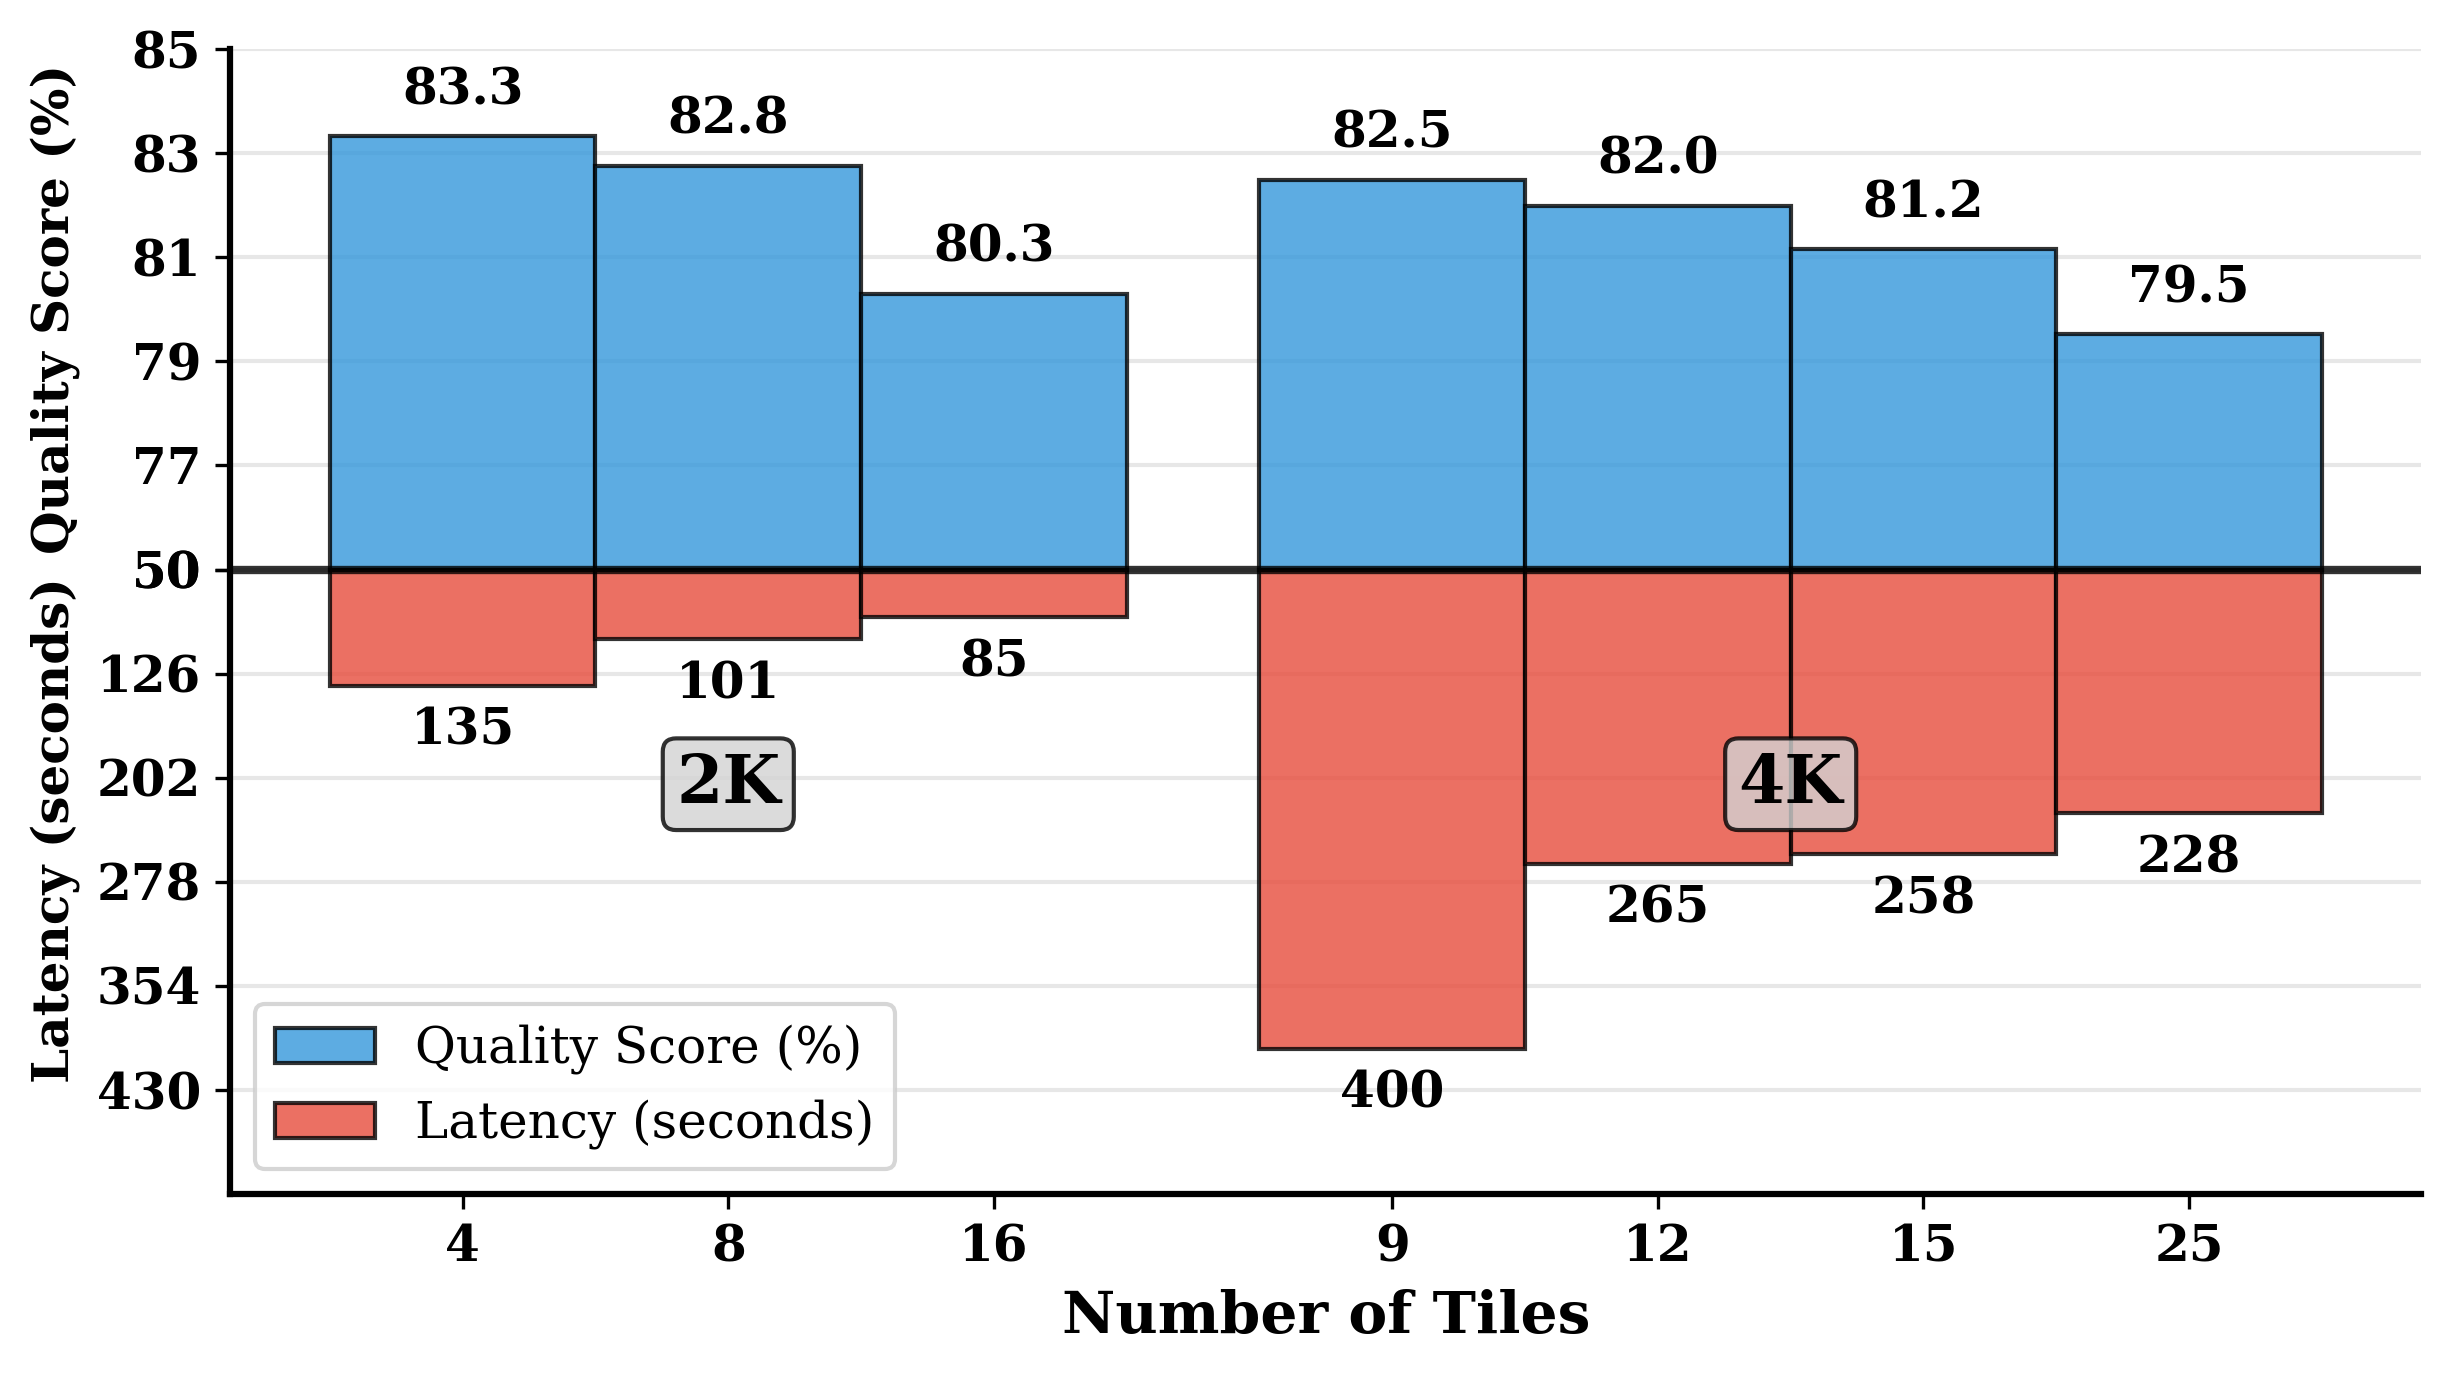

In [2]:
# Effect of Number of Tiles - 双向y轴图表
import matplotlib.pyplot as plt
import numpy as np

# 设置matplotlib参数 - 为小尺寸图表优化
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'font.family': 'serif',
    'text.usetex': False,
    'figure.dpi': 300
})

# 根据用户提供的数据
tiles_data = {
    '2K': {
        'num_tiles': [4, 8, 16],
        'v_avg': [83.324, 82.756, 80.302],
        'latency': [135, 101, 85],
        'settings': ['160x90', '80x90', '40x90']
    },
    '4K': {
        'num_tiles': [9, 12, 15, 25],
        'v_avg': [82.488, 81.988, 81.16,  79.524],
        'latency': [400, 265, 258, 228],
        'settings': ['160x90', '120x90', '160x54', '96x54']
    }
}

# 创建图表 - 为Overleaf优化的紧凑尺寸
fig, ax = plt.subplots(figsize=(8, 4.5))

# 设置柱状图参数 - 减少间距使图表更紧凑
resolutions = ['2K', '4K']
bar_width = 1.0  # 柱子宽度设为1，完全消除间隙
group_spacing = 0.5  # 进一步减少分组间的间距

# 颜色设置
color_v_avg = '#3498DB'    # 蓝色用于v-avg (上方)
color_latency = '#E74C3C'  # 红色用于latency (下方)

# 设置y轴范围参数
v_avg_min, v_avg_max = 75, 85  # 上方范围: 75-85
latency_min, latency_max = 50, 430  # 下方范围: 50-430

# 计算缩放比例，使上下占据相同高度
v_avg_range = v_avg_max - v_avg_min  # 25
latency_range = latency_max - latency_min  # 400
scale_factor = v_avg_range / latency_range  # 0.0625

# 计算每个分辨率组的位置
all_positions = []
all_labels = []
current_pos = 0

for res in resolutions:
    data = tiles_data[res]
    n_bars = len(data['num_tiles'])
    
    # 为当前分辨率组计算位置 - 让bars紧密相邻
    group_positions = np.arange(n_bars) * 1.0 + current_pos  # bars之间没有间隙
    all_positions.extend(group_positions)
    
    # 为每个瓦片数创建标签
    for i, (tiles, setting) in enumerate(zip(data['num_tiles'], data['settings'])):
        all_labels.append(f"{tiles}")
    
    # 绘制v-avg柱状图 (向上，从0基准开始，范围映射到0-25)
    normalized_v_avg = [(v - v_avg_min) for v in data['v_avg']]
    bars_v_avg = ax.bar(group_positions, normalized_v_avg, bar_width,
                       color=color_v_avg, alpha=0.8,
                       edgecolor='black', linewidth=1)
    
    # 绘制latency柱状图 (向下，按比例缩放)
    scaled_latency = [-(l - latency_min) * scale_factor for l in data['latency']]
    bars_latency = ax.bar(group_positions, scaled_latency, bar_width,
                         color=color_latency, alpha=0.8,
                         edgecolor='black', linewidth=1)
    
    # 添加数值标签
    for i, (bar_v, bar_l, v_val, l_val) in enumerate(zip(bars_v_avg, bars_latency, data['v_avg'], data['latency'])):
        # v-avg标签 (上方) - 调整字体大小
        ax.annotate(f'{v_val:.1f}',
                   xy=(bar_v.get_x() + bar_v.get_width() / 2, bar_v.get_height()),
                   xytext=(0, 5),
                   textcoords="offset points",
                   ha='center', va='bottom',
                   fontsize=12, fontweight='bold')
        
        # latency标签 (下方) - 调整字体大小
        ax.annotate(f'{l_val}',
                   xy=(bar_l.get_x() + bar_l.get_width() / 2, bar_l.get_height()),
                   xytext=(0, -5),
                   textcoords="offset points",
                   ha='center', va='top',
                   fontsize=12, fontweight='bold')
    
    # 更新下一组的起始位置 - 紧凑间距
    current_pos = group_positions[-1] + 1.0 + group_spacing

# 设置坐标轴 - 调整字体大小
ax.set_xlabel('Number of Tiles', fontsize=14, fontweight='bold')
# ax.set_title('Effect of Number of Tiles on Performance', fontsize=16, fontweight='bold')

# 添加分离的y轴标签 - 调整字体大小
# 上半部分标签 (Quality Score)
ax.text(-0.08, v_avg_range/2, 'Quality Score (%)', transform=ax.get_yaxis_transform(), 
        rotation=90, ha='center', va='center', 
        fontsize=12, fontweight='bold')

# 下半部分标签 (Latency)
ax.text(-0.08, -v_avg_range/2, 'Latency (seconds)', transform=ax.get_yaxis_transform(), 
        rotation=90, ha='center', va='center', 
        fontsize=12, fontweight='bold')

# 设置x轴刻度和标签 - 调整字体大小
ax.set_xticks(all_positions)
ax.set_xticklabels(all_labels, ha='center', fontsize=12, fontweight='bold')

# 添加分辨率组标签 (2K 和 4K)
# 根据实际的柱子位置计算每个分辨率组的中心
group_centers = []
pos_index = 0
for res in resolutions:
    n_bars = len(tiles_data[res]['num_tiles'])
    # 获取当前组的所有位置
    group_positions = all_positions[pos_index:pos_index + n_bars]
    # 计算组的中心位置
    group_center = (group_positions[0] + group_positions[-1]) / 2
    group_centers.append(group_center)
    pos_index += n_bars

# 在每个组下方添加分辨率标签 - 调整字体大小
y_offset = -v_avg_range * 0.35  # 在图表下方35%的位置
for i, (res, center) in enumerate(zip(resolutions, group_centers)):
    ax.text(center, y_offset, res, ha='center', va='top', 
            fontsize=16, fontweight='bold', 
            bbox=dict(boxstyle="round,pad=0.2", facecolor='lightgray', alpha=0.8))

# 添加水平分隔线在y=0处
ax.axhline(y=0, color='black', linewidth=2, alpha=0.8)

# 添加图例
legend_elements = [
    plt.Rectangle((0,0),1,1, facecolor=color_v_avg, alpha=0.8, edgecolor='black', label='Quality Score (%)'),
    plt.Rectangle((0,0),1,1, facecolor=color_latency, alpha=0.8, edgecolor='black', label='Latency (seconds)')
]
ax.legend(handles=legend_elements, loc='lower left', fontsize=12, frameon=True, fancybox=True)

# 设置网格
ax.grid(True, alpha=0.3, axis='y', linewidth=1)
ax.set_axisbelow(True)

# 设置y轴范围，使上下部分高度相等，并为分辨率标签留出空间
# 上方：从0到v_avg_range (0到25，高度25)
# 下方：从0到-v_avg_range*1.2 (为标签留出更多空间)
ax.set_ylim(-v_avg_range * 1.2, v_avg_range)

# 设置坐标轴样式
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

# 自定义y轴刻度和标签
# 上方刻度位置 (0到25，对应v-avg 75-100)
upper_tick_positions = np.linspace(0, v_avg_range, 6)  # 0, 5, 10, 15, 20, 25
upper_tick_labels = np.linspace(v_avg_min, v_avg_max, 6)  # 75, 80, 85, 90, 95, 100

# 下方刻度位置 (0到-25，对应latency 50-450)
lower_tick_positions = np.linspace(0, -v_avg_range, 6)  # 0, -5, -10, -15, -20, -25
lower_tick_labels = np.linspace(latency_min, latency_max, 6)  # 50, 130, 210, 290, 370, 450

# 合并所有刻度
all_ticks = list(upper_tick_positions) + list(lower_tick_positions)
all_labels = [f'{int(label)}' for label in upper_tick_labels] + [f'{int(label)}' for label in lower_tick_labels]

ax.set_yticks(all_ticks)
ax.set_yticklabels(all_labels)

# 设置y轴刻度标签为粗体
for label in ax.get_yticklabels():
    label.set_fontweight('bold')

# 调整布局 - 为Overleaf优化的紧凑设置
plt.tight_layout(pad=0.3)  # 进一步减少内边距

# 保存图表 - 为Overleaf优化的紧凑PDF设置
plt.savefig('tiles_effect_comparison.pdf', format='pdf', bbox_inches='tight', 
            dpi=300, facecolor='white', edgecolor='none', pad_inches=0.05)  # 最小外边距

# 显示图表
plt.show()


/var/folders/sw/02hnlx695qv0nqdx13hxby1m0000gn/T/ipykernel_86625/3803057905.py:194: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.4)


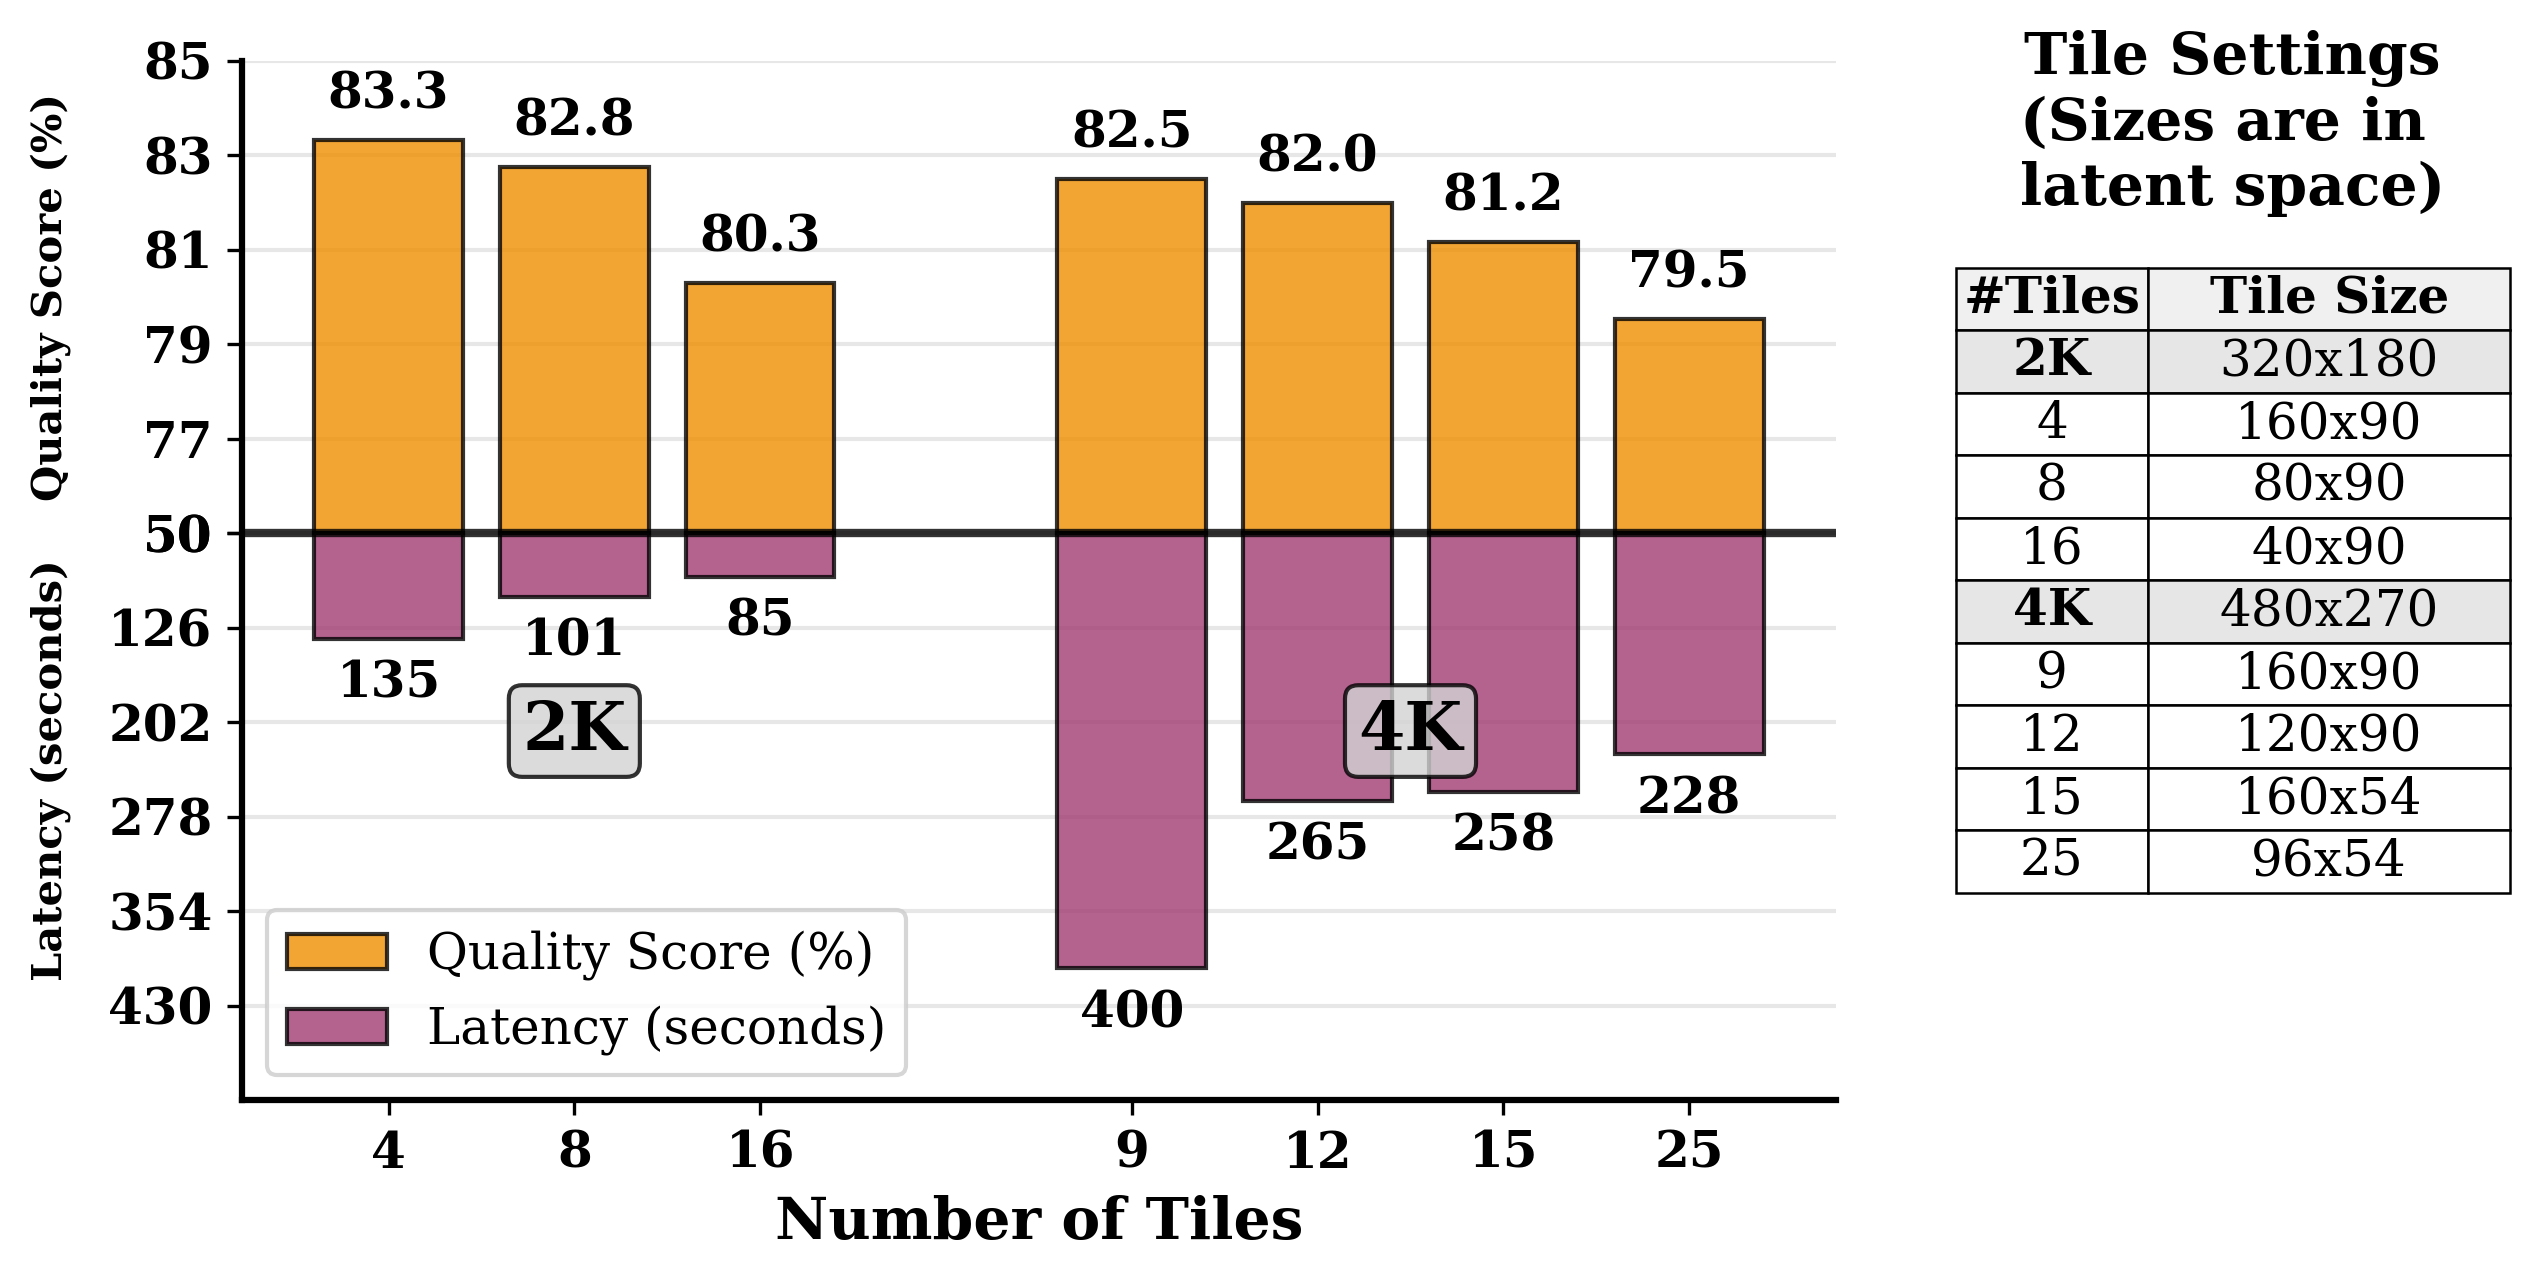

In [27]:
# Effect of Number of Tiles with right-side tile-size list (paper-ready)
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------- rcParams --------------------------------
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'font.family': 'serif',
    'text.usetex': False,
    'figure.dpi': 300
})

# ------------------------------- input data -------------------------------
tiles_data = {
    '2K': {
        'num_tiles': [4, 8, 16],
        'v_avg':     [83.324, 82.756, 80.302],
        'latency':   [135, 101, 85],
        'settings':  ['160x90', '80x90', '40x90']
    },
    '4K': {
        'num_tiles': [9, 12, 15, 25],
        'v_avg':     [82.488, 81.988, 81.16, 79.524],
        'latency':   [400, 265, 258, 228],
        'settings':  ['160x90', '120x90', '160x54', '96x54']
    }
}
resolutions   = ['2K', '4K']

# ------------------------------ figure layout -----------------------------
# Two columns: left = bars, right = compact table
fig, (ax, ax_tbl) = plt.subplots(
    1, 2, figsize=(9.6, 4.5),
    gridspec_kw={'width_ratios': [4.3, 1.3], 'wspace': 0.15}
)

# ------------------------------- main chart --------------------------------
bar_width     = 0.8
group_spacing = 1.0
color_v_avg   = '#F18F01'
color_latency = '#A23B72'

# y mapping
v_avg_min, v_avg_max = 75, 85
latency_min, latency_max = 50, 430
v_avg_range   = v_avg_max - v_avg_min
latency_range = latency_max - latency_min
scale_factor  = v_avg_range / latency_range

all_positions = []
xtick_labels  = []
current_pos   = 0

for res in resolutions:
    data = tiles_data[res]
    n = len(data['num_tiles'])
    group_pos = np.arange(n) * 1.0 + current_pos
    all_positions.extend(group_pos)
    xtick_labels.extend([str(t) for t in data['num_tiles']])

    # bars
    norm_v = [(v - v_avg_min) for v in data['v_avg']]
    bars_v = ax.bar(group_pos, norm_v, bar_width, color=color_v_avg,
                    alpha=0.8, edgecolor='black', linewidth=1)
    scaled_l = [-(l - latency_min) * scale_factor for l in data['latency']]
    bars_l = ax.bar(group_pos, scaled_l, bar_width, color=color_latency,
                    alpha=0.8, edgecolor='black', linewidth=1)

    # labels on bars
    for bv, bl, vval, lval in zip(bars_v, bars_l, data['v_avg'], data['latency']):
        ax.annotate(f'{vval:.1f}',
                    xy=(bv.get_x() + bv.get_width()/2, bv.get_height()),
                    xytext=(0, 5), textcoords="offset points",
                    ha='center', va='bottom', fontsize=12, fontweight='bold')
        ax.annotate(f'{lval}',
                    xy=(bl.get_x() + bl.get_width()/2, bl.get_height()),
                    xytext=(0, -5), textcoords="offset points",
                    ha='center', va='top', fontsize=12, fontweight='bold')

    current_pos = group_pos[-1] + 1.0 + group_spacing

# x-axis
ax.set_xticks(all_positions)
ax.set_xticklabels(xtick_labels, ha='center', fontsize=12, fontweight='bold')
ax.set_xlabel('Number of Tiles', fontsize=14, fontweight='bold')

# split y-labels
ax.text(-0.12, v_avg_range/2, 'Quality Score (%)',
        transform=ax.get_yaxis_transform(), rotation=90,
        ha='center', va='center', fontsize=10, fontweight='bold')
ax.text(-0.12, -v_avg_range/2, 'Latency (seconds)',
        transform=ax.get_yaxis_transform(), rotation=90,
        ha='center', va='center', fontsize=10, fontweight='bold')

# group tags (2K / 4K)
group_centers, pos_idx = [], 0
for res in resolutions:
    n = len(tiles_data[res]['num_tiles'])
    gp = all_positions[pos_idx:pos_idx+n]
    group_centers.append((gp[0] + gp[-1]) / 2)
    pos_idx += n
y_offset = -v_avg_range * 0.35
for res, center in zip(resolutions, group_centers):
    ax.text(center, y_offset, res, ha='center', va='top',
            fontsize=16, fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.2", facecolor='lightgray', alpha=0.8))

# cosmetics
ax.axhline(y=0, color='black', linewidth=2, alpha=0.8)
legend_elements = [
    plt.Rectangle((0,0),1,1, facecolor=color_v_avg, alpha=0.8, edgecolor='black', label='Quality Score (%)'),
    plt.Rectangle((0,0),1,1, facecolor=color_latency, alpha=0.8, edgecolor='black', label='Latency (seconds)')
]
ax.legend(handles=legend_elements, loc='lower left', fontsize=12, frameon=True, fancybox=True)
ax.grid(True, alpha=0.3, axis='y', linewidth=1)
ax.set_axisbelow(True)
ax.set_ylim(-v_avg_range * 1.2, v_avg_range)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

# y ticks (dual scale)
upper_pos   = np.linspace(0,  v_avg_range, 6)
upper_labels= np.linspace(v_avg_min, v_avg_max, 6)
lower_pos   = np.linspace(0, -v_avg_range, 6)
lower_labels= np.linspace(latency_min, latency_max, 6)
ax.set_yticks(list(upper_pos) + list(lower_pos))
ax.set_yticklabels([f'{int(x)}' for x in upper_labels] + [f'{int(x)}' for x in lower_labels])
for lab in ax.get_yticklabels(): lab.set_fontweight('bold')

# ----------------------- right-side table: tile sizes ----------------------
# Build ordered rows matching the x-axis order
rows = []
section_row_idx = []   # remember where 2K/4K headers are placed
for res in resolutions:
    section_row_idx.append(len(rows))
    if res == "2K":
        complete = "320x180"
    elif res == "4K":
        complete = "480x270"
    rows.append([res, complete])  # section header row
    for tiles, setting in zip(tiles_data[res]['num_tiles'], tiles_data[res]['settings']):
        rows.append([str(tiles), setting])

# Draw table
ax_tbl.axis('off')
tbl = ax_tbl.table(
    cellText=rows,
    colLabels=['#Tiles', 'Tile Size'],
    cellLoc='center',
    colLoc='center',
    loc='center',
    colWidths=[0.40, 0.75]
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(12)
tbl.scale(1.0, 1.25)
# ax_tbl.set_title('Tile Settings\n(Sizes are in \nlatent space)', fontsize=14, fontweight='bold', pad=0)
ax_tbl.text(
    0.5, 0.85,  # (x, y) in axis coordinates
    'Tile Settings\n(Sizes are in \nlatent space)',
    ha='center', va='bottom',
    fontsize=14, fontweight='bold',
    transform=ax_tbl.transAxes
)

# Style: bold header row + gray section headers
# Header row is row index 0 inside the Table; data rows start at 1.
# Convert section indices from data-space to table-space (+1 for header).
for r in range(len(rows)+1):           # +1 to include header
    for c in range(2):
        cell = tbl[(r, c)]
        cell.set_edgecolor('black')
        cell.set_linewidth(0.6)

# make table header bold
for c in range(2):
    tbl[(0, c)].set_facecolor('#f0f0f0')
    tbl[(0, c)].get_text().set_fontweight('bold')

# section headers (2K / 4K)
for s in section_row_idx:
    tr = s + 1  # table row index
    tbl[(tr, 0)].get_text().set_fontweight('bold')
    tbl[(tr, 0)].set_facecolor('#e6e6e6')
    tbl[(tr, 1)].set_facecolor('#e6e6e6')

plt.tight_layout(pad=0.4)
plt.savefig('tiles_effect_with_tile_sizes.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()


/tmp/ipykernel_3629209/337510833.py:194: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.4)


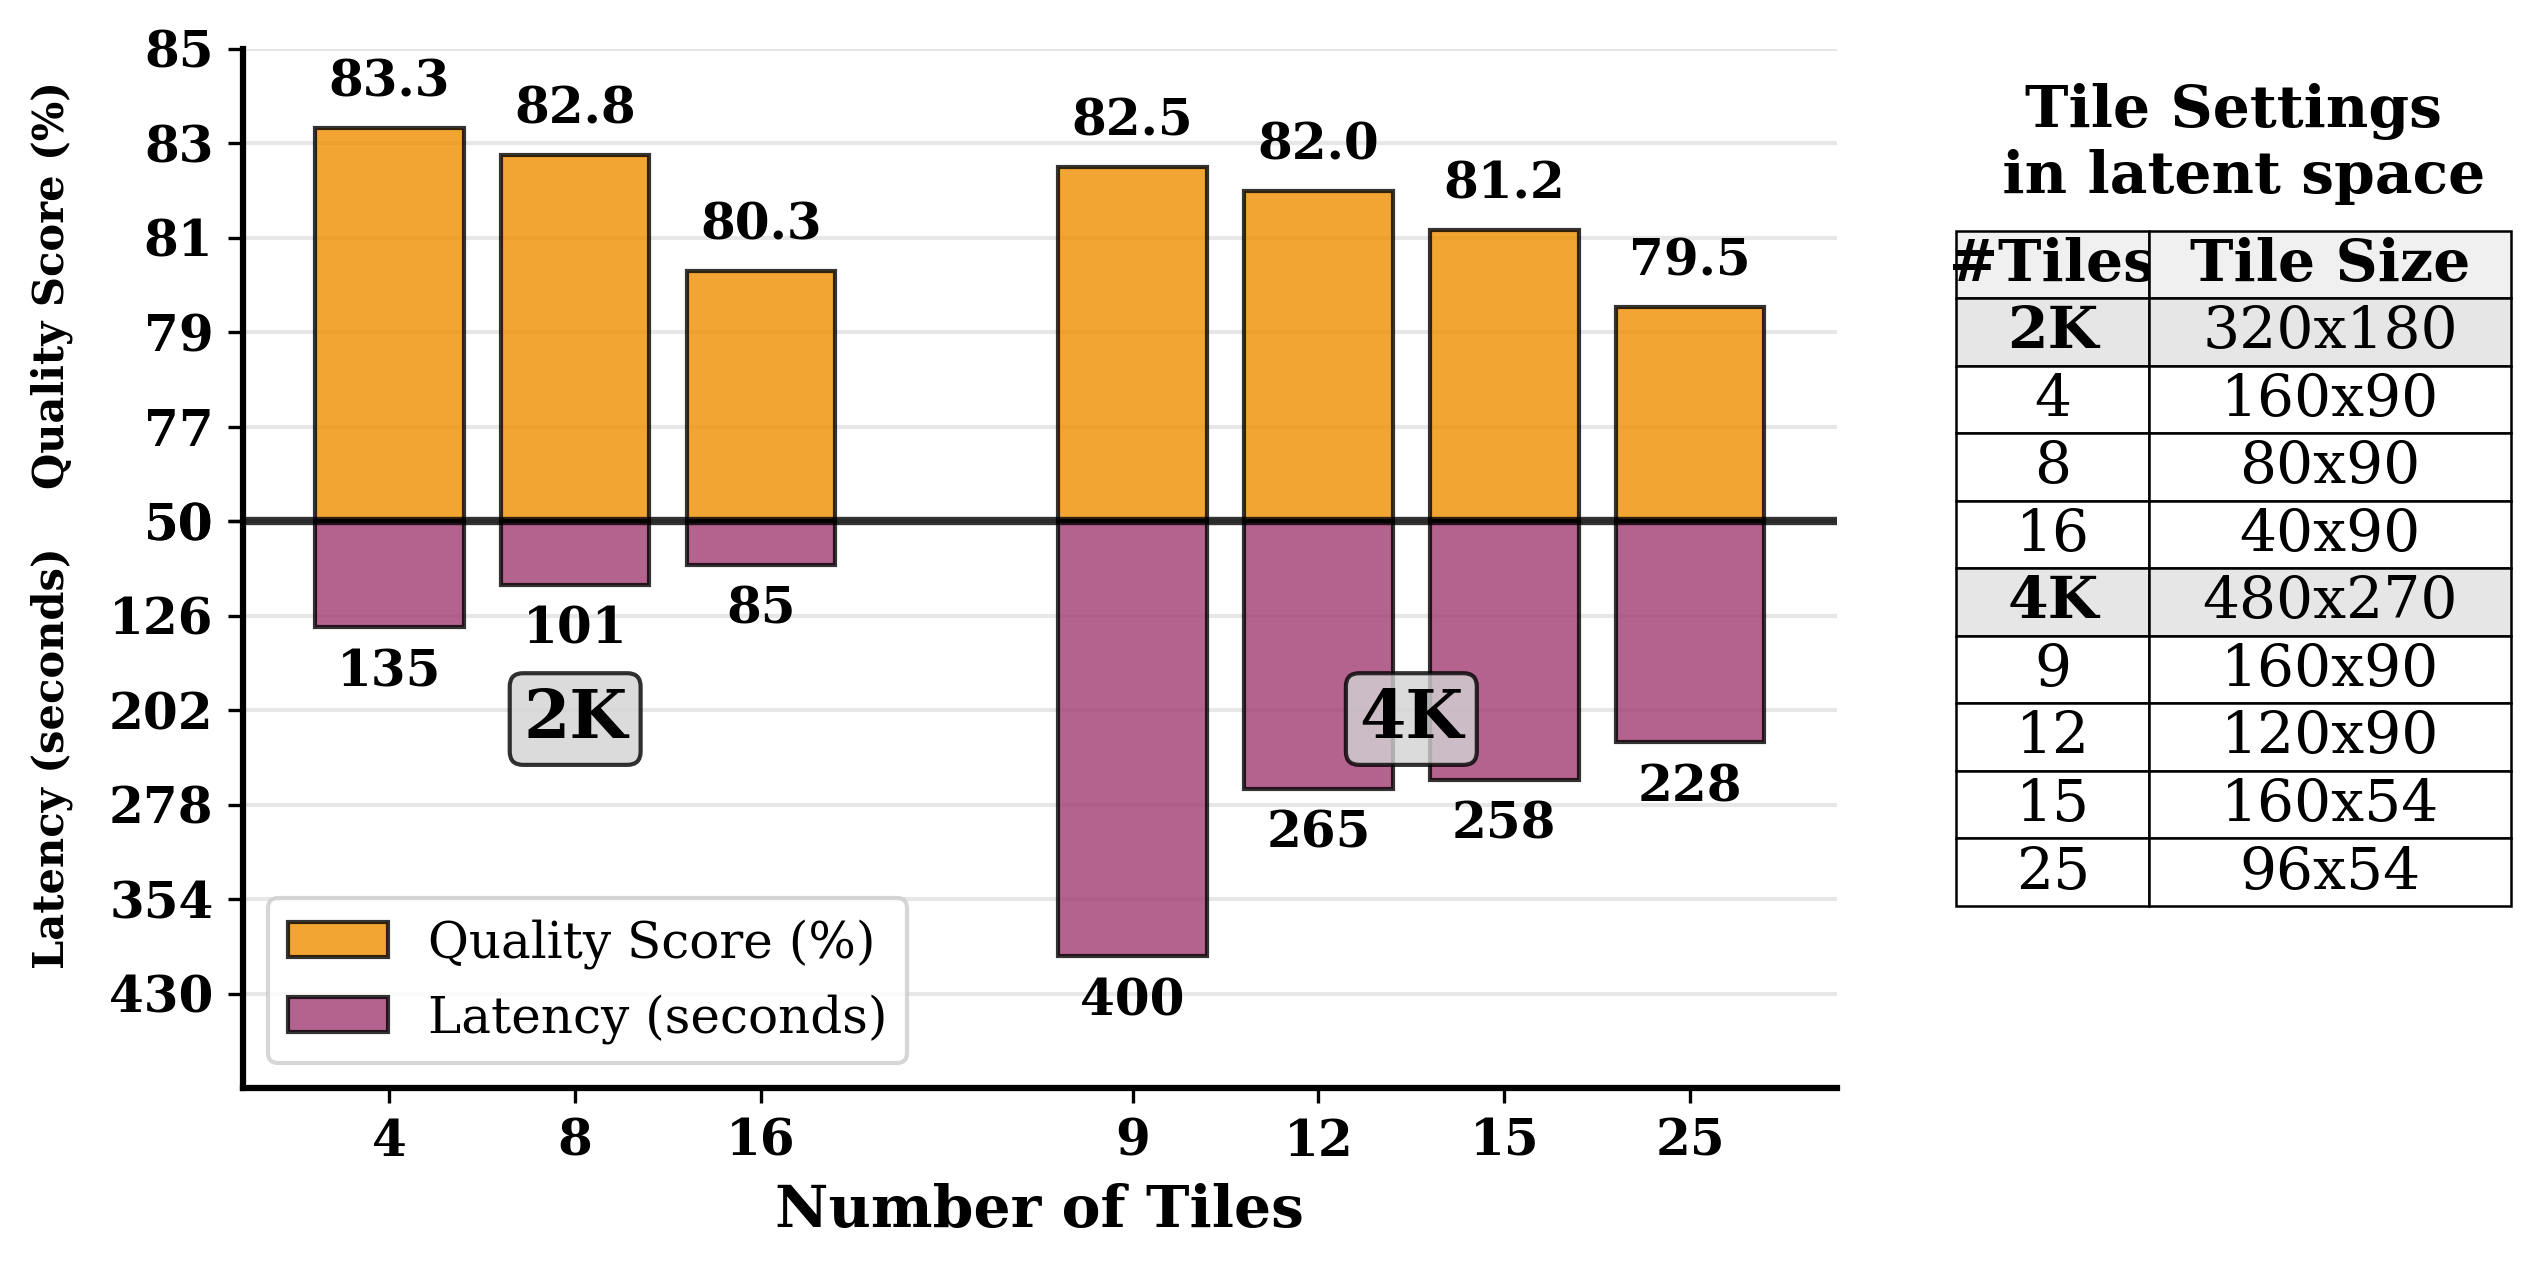

In [4]:
# Effect of Number of Tiles with right-side tile-size list (paper-ready)
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------- rcParams --------------------------------
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'font.family': 'serif',
    'text.usetex': False,
    'figure.dpi': 300
})

# ------------------------------- input data -------------------------------
tiles_data = {
    '2K': {
        'num_tiles': [4, 8, 16],
        'v_avg':     [83.324, 82.756, 80.302],
        'latency':   [135, 101, 85],
        'settings':  ['160x90', '80x90', '40x90']
    },
    '4K': {
        'num_tiles': [9, 12, 15, 25],
        'v_avg':     [82.488, 81.988, 81.16, 79.524],
        'latency':   [400, 265, 258, 228],
        'settings':  ['160x90', '120x90', '160x54', '96x54']
    }
}
resolutions   = ['2K', '4K']

# ------------------------------ figure layout -----------------------------
# Two columns: left = bars, right = compact table
fig, (ax, ax_tbl) = plt.subplots(
    1, 2, figsize=(9.6, 4.5),
    gridspec_kw={'width_ratios': [4.3, 1.3], 'wspace': 0.15}
)

# ------------------------------- main chart --------------------------------
bar_width     = 0.8
group_spacing = 1.0
color_v_avg   = '#F18F01'
color_latency = '#A23B72'

# y mapping
v_avg_min, v_avg_max = 75, 85
latency_min, latency_max = 50, 430
v_avg_range   = v_avg_max - v_avg_min
latency_range = latency_max - latency_min
scale_factor  = v_avg_range / latency_range

all_positions = []
xtick_labels  = []
current_pos   = 0

for res in resolutions:
    data = tiles_data[res]
    n = len(data['num_tiles'])
    group_pos = np.arange(n) * 1.0 + current_pos
    all_positions.extend(group_pos)
    xtick_labels.extend([str(t) for t in data['num_tiles']])

    # bars
    norm_v = [(v - v_avg_min) for v in data['v_avg']]
    bars_v = ax.bar(group_pos, norm_v, bar_width, color=color_v_avg,
                    alpha=0.8, edgecolor='black', linewidth=1)
    scaled_l = [-(l - latency_min) * scale_factor for l in data['latency']]
    bars_l = ax.bar(group_pos, scaled_l, bar_width, color=color_latency,
                    alpha=0.8, edgecolor='black', linewidth=1)

    # labels on bars
    for bv, bl, vval, lval in zip(bars_v, bars_l, data['v_avg'], data['latency']):
        ax.annotate(f'{vval:.1f}',
                    xy=(bv.get_x() + bv.get_width()/2, bv.get_height()),
                    xytext=(0, 5), textcoords="offset points",
                    ha='center', va='bottom', fontsize=12, fontweight='bold')
        ax.annotate(f'{lval}',
                    xy=(bl.get_x() + bl.get_width()/2, bl.get_height()),
                    xytext=(0, -5), textcoords="offset points",
                    ha='center', va='top', fontsize=12, fontweight='bold')

    current_pos = group_pos[-1] + 1.0 + group_spacing

# x-axis
ax.set_xticks(all_positions)
ax.set_xticklabels(xtick_labels, ha='center', fontsize=12, fontweight='bold')
ax.set_xlabel('Number of Tiles', fontsize=14, fontweight='bold')

# split y-labels
ax.text(-0.12, v_avg_range/2, 'Quality Score (%)',
        transform=ax.get_yaxis_transform(), rotation=90,
        ha='center', va='center', fontsize=10, fontweight='bold')
ax.text(-0.12, -v_avg_range/2, 'Latency (seconds)',
        transform=ax.get_yaxis_transform(), rotation=90,
        ha='center', va='center', fontsize=10, fontweight='bold')

# group tags (2K / 4K)
group_centers, pos_idx = [], 0
for res in resolutions:
    n = len(tiles_data[res]['num_tiles'])
    gp = all_positions[pos_idx:pos_idx+n]
    group_centers.append((gp[0] + gp[-1]) / 2)
    pos_idx += n
y_offset = -v_avg_range * 0.35
for res, center in zip(resolutions, group_centers):
    ax.text(center, y_offset, res, ha='center', va='top',
            fontsize=16, fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.2", facecolor='lightgray', alpha=0.8))

# cosmetics
ax.axhline(y=0, color='black', linewidth=2, alpha=0.8)
legend_elements = [
    plt.Rectangle((0,0),1,1, facecolor=color_v_avg, alpha=0.8, edgecolor='black', label='Quality Score (%)'),
    plt.Rectangle((0,0),1,1, facecolor=color_latency, alpha=0.8, edgecolor='black', label='Latency (seconds)')
]
ax.legend(handles=legend_elements, loc='lower left', fontsize=12, frameon=True, fancybox=True)
ax.grid(True, alpha=0.3, axis='y', linewidth=1)
ax.set_axisbelow(True)
ax.set_ylim(-v_avg_range * 1.2, v_avg_range)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

# y ticks (dual scale)
upper_pos   = np.linspace(0,  v_avg_range, 6)
upper_labels= np.linspace(v_avg_min, v_avg_max, 6)
lower_pos   = np.linspace(0, -v_avg_range, 6)
lower_labels= np.linspace(latency_min, latency_max, 6)
ax.set_yticks(list(upper_pos) + list(lower_pos))
ax.set_yticklabels([f'{int(x)}' for x in upper_labels] + [f'{int(x)}' for x in lower_labels])
for lab in ax.get_yticklabels(): lab.set_fontweight('bold')

# ----------------------- right-side table: tile sizes ----------------------
# Build ordered rows matching the x-axis order
rows = []
section_row_idx = []   # remember where 2K/4K headers are placed
for res in resolutions:
    section_row_idx.append(len(rows))
    if res == "2K":
        complete = "320x180"
    elif res == "4K":
        complete = "480x270"
    rows.append([res, complete])  # section header row
    for tiles, setting in zip(tiles_data[res]['num_tiles'], tiles_data[res]['settings']):
        rows.append([str(tiles), setting])

# Draw table
ax_tbl.axis('off')
tbl = ax_tbl.table(
    cellText=rows,
    colLabels=['#Tiles', 'Tile Size'],
    cellLoc='center',
    colLoc='center',
    loc='center',
    colWidths=[0.40, 0.75]
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(14)
tbl.scale(1.0, 1.35)
# ax_tbl.set_title('Tile Settings\n(Sizes are in \nlatent space)', fontsize=14, fontweight='bold', pad=0)
ax_tbl.text(
    0.5, 0.85,  # (x, y) in axis coordinates
    'Tile Settings\n in latent space',
    ha='center', va='bottom',
    fontsize=14, fontweight='bold',
    transform=ax_tbl.transAxes
)

# Style: bold header row + gray section headers
# Header row is row index 0 inside the Table; data rows start at 1.
# Convert section indices from data-space to table-space (+1 for header).
for r in range(len(rows)+1):           # +1 to include header
    for c in range(2):
        cell = tbl[(r, c)]
        cell.set_edgecolor('black')
        cell.set_linewidth(0.6)

# make table header bold
for c in range(2):
    tbl[(0, c)].set_facecolor('#f0f0f0')
    tbl[(0, c)].get_text().set_fontweight('bold')

# section headers (2K / 4K)
for s in section_row_idx:
    tr = s + 1  # table row index
    tbl[(tr, 0)].get_text().set_fontweight('bold')
    tbl[(tr, 0)].set_facecolor('#e6e6e6')
    tbl[(tr, 1)].set_facecolor('#e6e6e6')

plt.tight_layout(pad=0.4)
plt.savefig('tiles_effect_with_tile_sizes.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.show()


In [ ]:
# pseudo code for two stage generation
# model = original_pipeline  # NOTE: illustrative pseudocode only (original_pipeline undefined); commented out so the notebook runs headlessly. Not a plotting cell.
def two_stage_generation(image, prompt):
    low_res_latent = low_res_gen(image, prompt)
    upscaled_latent = upscale(low_res_latent)
    return high_res_gen(upscaled_latent, prompt)
def low_res_gen(image, prompt):
    return model(image, prompt)
def upscale(low_res_latent):
    pixel_video = model.decode(low_res_latent)
    upscaled_pixel = interpolate(pixel_video)
    high_res_latent = model.encode(upscaled_pixel)
    return add_noise(high_res_latent, denoising_steps)
def high_res_gen(latent, prompt):
    tiles = parition_tiles(latent.shape, tile_size)
    for i in range(denoising_steps):
        if shift_this_step:
            tiles = shift(tiles)
        local_noise_tiles = []
        for tile in tiles:
            latent_tile = slice_tile(latent, tile)
            noise_tile = model.DiT(latent_tile, i)
            local_noise_tiles.append(noise_tile)
        noise = fuser(local_noise_tiles)
        latent = denoise(latent, noise)
    return model.decode(latent)